# Predicción de cancelación de clientes — Interconnect

**Caso:** Interconnect, operador de telecomunicaciones.
**Pregunta de negocio:** ¿qué clientes están por cancelar y en qué orden conviene contactarlos para ofrecer una acción de retención?
**Fecha de corte de los datos:** 1 de febrero de 2020. **Cobertura:** 7 043 clientes únicos con altas desde octubre de 2013.

## 1. Planteamiento del problema

Interconnect pierde clientes y, con ellos, ingresos recurrentes. El objetivo es **detectar con antelacion a los clientes con mayor probabilidad de cancelar** para que marketing pueda contactarlos con ofertas de retencion antes de que se vayan.

El modelo se evaluara con **AUC-ROC**, una metrica que mide que tan bien ordena a los clientes por riesgo de cancelacion. Una lectura directa:
- **0.50** = el modelo no distingue (azar puro).
- **0.75** = acierta el orden el 75 % de las veces al comparar un cliente que canceló contra uno que se quedó.
- **1.00** = separacion perfecta.

Esta metrica no depende del umbral de corte, por lo que nos da una lectura honesta incluso con las clases desbalanceadas.

### Estrategia de análisis

1. **Carga, auditoría y unificación.** Se leen los cuatro archivos de origen, se revisa la calidad de cada uno (tipos, nulos, duplicados) y se unen por `CustomerID` usando como base la tabla de contrato, que tiene cobertura completa. La ausencia de un cliente en las tablas de internet o teléfono se interpreta como *no contrató ese servicio*, no como dato faltante.
2. **Construcción de variables con sentido comercial.** Se agregan tres columnas a partir de los datos crudos: la variable objetivo `Churn` (canceló / sigue activo), la antigüedad del cliente en días (`DaysActive`) y el **LTV**, que representa el valor económico acumulado: lo que cada cliente ha pagado durante su relación con la empresa.
3. **Análisis por segmento.** Se revisan las cancelaciones por tipo de contrato y por año de alta, para ubicar en qué parte de la cartera se concentra el problema.
4. **Cuantificación del impacto económico.** Se calcula cuánto dinero representa la fuga, en total y por segmento.
5. **Validación estadística.** Se comprueba que las diferencias entre clientes activos y cancelados no se explican por azar.


## 2. Datos

La información del caso se distribuye en cuatro archivos CSV provenientes de los sistemas internos de Interconnect: contrato, datos personales, servicios de internet y servicios telefónicos. Los cuatro se unen por el identificador de cada cliente.


### Fuentes

La información proviene de cuatro archivos CSV con orígenes distintos:

- `contract.csv` — información del contrato.
- `personal.csv` — datos personales del cliente.
- `internet.csv` — servicios de internet contratados.
- `phone.csv` — servicios telefónicos contratados.

En todos los archivos, la columna `customerID` contiene un código único asignado a cada cliente y funciona como llave de unión. La información abarca las altas desde octubre de 2013 hasta la **fecha de corte: 1 de febrero de 2020**. A esa fecha se sabe, para cada cliente, si seguía activo o si ya había cancelado.

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "torch")  # Keras 3 con backend torch (GPU en Windows).

import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats

from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import keras
from keras import layers

RANDOM_SEED = 56789

In [2]:
# Rutas y carga de los cuatro CSV de origen.
FOLDER   = Path.cwd().parent
DATABASE = FOLDER / 'Data'

contract = pd.read_csv(DATABASE / 'contract.csv')
internet = pd.read_csv(DATABASE / 'internet.csv')
personal = pd.read_csv(DATABASE / 'personal.csv')
phone    = pd.read_csv(DATABASE / 'phone.csv')

print(contract.shape, internet.shape, personal.shape, phone.shape)

(7043, 8) (5517, 8) (7043, 5) (6361, 2)


### Estandarización de columnas

Los cuatro archivos llegan con nombres de columna heterogéneos (unos en minúsculas, otros con mezclas). Para evitar fricción al unirlos, se unifican a una sola convención que capitaliza la primera letra y conserva las mayúsculas internas: `customerID` se convierte en `CustomerID` y `MonthlyCharges` permanece igual. Es un detalle técnico sin impacto en el análisis.


In [3]:
datasets = [contract, internet, phone, personal]

### Funciones auxiliares

Utilidades internas para estandarizar nombres, convertir tipos y levantar la auditoría de cada tabla. El lector no técnico puede saltarse este bloque.

In [4]:
# Normaliza los nombres de columnas a PascalCase in-place.
# Preserva las mayúsculas internas: customerID -> CustomerID, MonthlyCharges sigue igual.
def PascalCase(datasets):
    for dataset in datasets:
        dataset.columns = dataset.columns.str[0].str.upper() + dataset.columns.str[1:]

In [5]:
# Aplica la estandarización a las cuatro tablas.
PascalCase(datasets)

In [6]:
# Convierte df[col] de texto a numérico; valores no convertibles -> NaN.
def str_to_int(df, col):
    return pd.to_numeric(df[col], errors='coerce')

In [7]:
# Reporta los 5 valores menos frecuentes de cada columna: útil para detectar outliers de texto.
def out_la(data_frames):
    for col in data_frames.columns:
        kind = 'Text' if data_frames[col].dtype == 'object' else 'Numeric'
        print(f'--- {kind}: {col} ---')
        print(data_frames[col].value_counts().sort_values().tail(), '\n')

In [8]:
# Convierte columnas Yes/No/True/False/1/0 a booleano real.
def str_to_bool(df, cols):
    mapa = {'yes': True, 'no': False, 'true': True, 'false': False, '1': True, '0': False}
    for col in cols:
        df[col] = df[col].astype(str).str.strip().str.lower().map(mapa)
    return df

## 3. Auditoría de calidad por dataset

Antes de cualquier transformación se realiza una auditoría estandarizada de cada uno de los cuatro datasets. La función auxiliar `eda()` reporta, en una sola llamada: tamaño y consumo de memoria, tipos de dato, conteo de nulos, valores únicos por columna, filas duplicadas y una vista previa de los registros. Esto permite detectar de manera consistente qué transformaciones requiere cada tabla.

In [9]:
# Auditoría estandarizada: tamaño, tipos, descriptivos, nulos, únicos, duplicados y muestra.
def eda(df, name='DataFrame'):
    print(f'EDA — {name}')
    print(f'Filas x Columnas : {df.shape}')
    print(f'Memoria          : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

    print('\n— Tipos de datos —')
    display(df.dtypes)

    print('\n— Info —')
    df.info()

    print('\n— Estadísticas descriptivas —')
    display(df.describe(include='all').T)

    print('\n— Valores nulos —')
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print('Sin valores nulos.')
    else:
        nulls_df = pd.DataFrame({
            'nulos'  : nulls,
            'nulos_%': (nulls / len(df) * 100).round(2),
        }).sort_values('nulos', ascending=False)
        display(nulls_df)

    print('\n— Valores únicos por columna —')
    display(df.nunique().sort_values())

    print('\n— Duplicados —')
    dups = df.duplicated().sum()
    print(f'Filas duplicadas: {dups}')
    if dups > 0:
        display(df[df.duplicated(keep=False)].head())

    print('\n— Primeras 20 filas —')
    display(df.head(20))

### 3.1 Contract

La tabla de contratos es la columna vertebral del análisis: tiene un renglón por cliente y concentra las variables económicas clave (tipo de contrato, cargos mensuales, cargos totales) junto con las fechas de alta y baja.


In [10]:
eda(contract)

EDA — DataFrame
Filas x Columnas : (7043, 8)
Memoria          : 2854.9 KB

— Tipos de datos —


CustomerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

— Estadísticas descriptivas —


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,5248-YGIJN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BeginDate,7043,77,01/02/2014,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EndDate,7043,5,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,7043,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBilling,7043,2,Yes,4171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,7043,4,Electronic check,2365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,7043.0,NaN,NaN,NaN,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
TotalCharges,7043,6531,20.2,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN



— Valores nulos —
Sin valores nulos.

— Valores únicos por columna —


PaperlessBilling       2
Type                   3
PaymentMethod          4
EndDate                5
BeginDate             77
MonthlyCharges      1585
TotalCharges        6531
CustomerID          7043
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,5248-YGIJN,01/02/2014,No,Two year,Yes,Credit card (automatic),90.25,6369.45
1,6234-RAAPL,01/02/2014,No,Two year,No,Bank transfer (automatic),99.90,7251.7
2,5954-BDFSG,01/02/2014,No,Two year,Yes,Credit card (automatic),107.50,7853.7
3,0526-SXDJP,01/02/2014,No,Two year,No,Bank transfer (automatic),42.10,2962
4,9848-JQJTX,01/02/2014,No,Two year,Yes,Bank transfer (automatic),100.90,7459.05
5,6728-DKUCO,01/02/2014,No,One year,Yes,Electronic check,104.15,7303.05
6,2848-YXSMW,01/02/2014,No,Two year,No,Credit card (automatic),19.40,1363.25
7,6734-PSBAW,01/02/2014,No,Two year,Yes,Bank transfer (automatic),23.55,1723.95
8,3146-MSEGF,01/02/2014,No,Two year,Yes,Credit card (automatic),88.05,6425.65
9,5997-OPVFA,01/02/2014,No,Two year,Yes,Bank transfer (automatic),89.05,6254.45


In [11]:
out_la(contract)

--- Text: CustomerID ---
CustomerID
0616-ATFGB    1
5909-ECHUI    1
1062-LHZOD    1
9248-OJYKK    1
4415-IJZTP    1
Name: count, dtype: int64 

--- Text: BeginDate ---
BeginDate
01/01/2020    233
01/09/2019    237
01/11/2019    237
01/10/2019    237
01/02/2014    366
Name: count, dtype: int64 

--- Text: EndDate ---
EndDate
01/10/2019 00:00     458
01/01/2020 00:00     460
01/12/2019 00:00     466
01/11/2019 00:00     485
No                  5174
Name: count, dtype: int64 

--- Text: Type ---
Type
One year          1473
Two year          1695
Month-to-month    3875
Name: count, dtype: int64 

--- Text: PaperlessBilling ---
PaperlessBilling
No     2872
Yes    4171
Name: count, dtype: int64 

--- Text: PaymentMethod ---
PaymentMethod
Credit card (automatic)      1522
Bank transfer (automatic)    1544
Mailed check                 1612
Electronic check             2365
Name: count, dtype: int64 

--- Numeric: MonthlyCharges ---
MonthlyCharges
19.65    43
19.90    44
19.95    44
19.85    45

In [12]:
# Valores en blanco en TotalCharges — ver cuáles y cuántos.
contract['TotalCharges'].value_counts().sort_values().tail()

TotalCharges
19.65     8
20.05     8
19.75     9
20.2     11
         11
Name: count, dtype: int64

En la columna `TotalCharges` aparecen valores en blanco. Corresponden a clientes de alta muy reciente, sin primer cargo registrado todavía.

In [13]:
# Clientes con TotalCharges en blanco: altas recientes sin historial de cargos.
contract[contract['TotalCharges'] == ' ']

,CustomerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5163,4472-LVYGI,01/02/2020,No,Two year,Yes,Bank transfer (automatic),52.55,
5164,3115-CZMZD,01/02/2020,No,Two year,No,Mailed check,20.25,
5165,5709-LVOEQ,01/02/2020,No,Two year,No,Mailed check,80.85,
5166,4367-NUYAO,01/02/2020,No,Two year,No,Mailed check,25.75,
5167,1371-DWPAZ,01/02/2020,No,Two year,No,Credit card (automatic),56.05,
5168,7644-OMVMY,01/02/2020,No,Two year,No,Mailed check,19.85,
5169,3213-VVOLG,01/02/2020,No,Two year,No,Mailed check,25.35,
5170,2520-SGTTA,01/02/2020,No,Two year,No,Mailed check,20.00,
5171,2923-ARZLG,01/02/2020,No,One year,Yes,Mailed check,19.70,
5172,4075-WKNIU,01/02/2020,No,Two year,No,Mailed check,73.35,


Los valores vacíos están asociados a cuentas nuevas, sin historia de cargos.

In [14]:
# Convertir TotalCharges a numérico; los blancos quedan como NaN.
contract['TotalCharges'] = str_to_int(contract, 'TotalCharges')

Se convierte `TotalCharges` a numérico; los blancos quedan como `NaN`.

In [15]:
# Verificación: cola superior ahora en numérico.
contract['TotalCharges'].value_counts().sort_values().tail()

TotalCharges
19.90     8
20.05     8
19.65     8
19.75     9
20.20    11
Name: count, dtype: int64

In [16]:
# Crear Churn, normalizar fechas y calcular dos medidas de antiguedad.
# Bloque idempotente: solo actua si EndDate sigue siendo string.
if contract['EndDate'].dtype == 'object':
    contract['Churn']   = contract['EndDate'] != 'No'
    contract['EndDate'] = contract['EndDate'].replace('No', '2020-02-01 00:00:00')
    contract['EndDate'] = pd.to_datetime(contract['EndDate'], format='mixed')
if contract['BeginDate'].dtype == 'object':
    contract['BeginDate'] = pd.to_datetime(contract['BeginDate'], format='mixed')

# DaysActive: vida util del cliente (para LTV y analisis descriptivo).
# Tenure: tiempo desde alta hasta la fecha de corte, IGUAL para todos los clientes
# (se usa en el modelo para evitar fuga: DaysActive filtra Churn por construccion).
CORTE = pd.to_datetime('2020-02-01')
contract['DaysActive'] = (contract['EndDate'] - contract['BeginDate']).dt.days
contract['Tenure'] = (CORTE - contract['BeginDate']).dt.days

contract.dtypes

CustomerID                  object
BeginDate           datetime64[ns]
EndDate             datetime64[ns]
Type                        object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                         bool
DaysActive                   int64
Tenure                       int64
dtype: object

Se agrega la columna `Automatic` para medir si el pago automático incide en la cancelación.

In [17]:
# Automatic = True si el método de pago es automático (bank transfer o credit card automatic).
contract['Automatic'] = contract['PaymentMethod'].str.lower().str.contains('automatic', na=False)

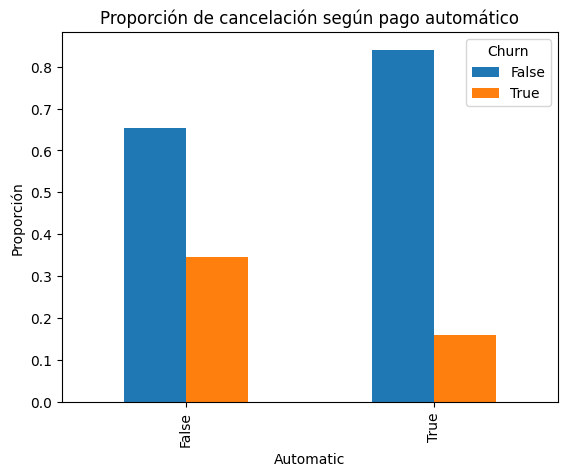

Churn,False,True
Automatic,,
False,0.653256,0.346744
True,0.840183,0.159817


In [18]:
# Proporción de cancelación según si el cliente tiene o no pago automático.
tabla_auto = pd.crosstab(contract['Automatic'], contract['Churn'], normalize='index')

tabla_auto.plot(kind='bar')
plt.xlabel('Automatic')
plt.ylabel('Proporción')
plt.title('Proporción de cancelación según pago automático')
plt.show()

tabla_auto

**Lectura.** Los clientes sin pago automático cancelan el **34.7 %**; los que lo tienen activado, solo el **16.0 %**. La fricción de pagar manualmente cada mes y el hecho de que quien activa el auto-pago ya tiene mayor compromiso explican el contraste. Es una variable predictiva útil y, además, una palanca comercial (incentivar la migración a auto-pago).

In [19]:
# Correlación entre las tres variables numéricas del contrato.
contract[['MonthlyCharges', 'TotalCharges', 'DaysActive']].corr()

,MonthlyCharges,TotalCharges,DaysActive
MonthlyCharges,1.000000,0.651065,0.211504
TotalCharges,0.651065,1.000000,0.797775
DaysActive,0.211504,0.797775,1.000000


**Lectura.** `TotalCharges` está altamente correlacionada con `DaysActive` (0.80): a más antigüedad, más gasto acumulado. `MonthlyCharges` y `DaysActive` son prácticamente independientes (0.21). Al modelar conviene descartar `TotalCharges` para evitar multicolinealidad, ya que es casi una función de las otras dos.

El pago automático se confirma como variable relacionada con la retención. Queda pendiente validarla con la prueba estadística más adelante.

In [20]:
# Vista rápida con las columnas derivadas.
contract[['CustomerID', 'BeginDate', 'EndDate', 'DaysActive', 'Churn', 'Automatic']].head()

,CustomerID,BeginDate,EndDate,DaysActive,Churn,Automatic
0,5248-YGIJN,2014-01-02,2020-02-01,2221,False,True
1,6234-RAAPL,2014-01-02,2020-02-01,2221,False,True
2,5954-BDFSG,2014-01-02,2020-02-01,2221,False,True
3,0526-SXDJP,2014-01-02,2020-02-01,2221,False,True
4,9848-JQJTX,2014-01-02,2020-02-01,2221,False,True


In [21]:
# Proporción de cancelación según facturación electrónica.
pd.crosstab(contract['PaperlessBilling'], contract['Churn'], normalize='index')

Churn,False,True
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


**Lectura.** La facturación electrónica coincide con una tasa de cancelación del **33.6 %**, el doble que la facturación en papel (16.3 %). No es causa directa: marca un perfil de cliente más digital y con mayor facilidad para cambiarse de proveedor. Se mantiene como variable predictiva, pero no es palanca accionable.

In [22]:
# Discretización de la antigüedad en tramos y tasa de cancelación por tramo.
contract['DaysActiveGroup'] = pd.cut(
    contract['DaysActive'],
    bins=[0, 180, 365, 730, 1460, contract['DaysActive'].max()],
    labels=['0-6 meses', '6-12 meses', '1-2 años', '2-4 años', '4+ años'],
    include_lowest=True,
)
tabla_antig = pd.crosstab(contract['DaysActiveGroup'], contract['Churn'], normalize='index')
print(tabla_antig[True].round(3))

DaysActiveGroup
0-6 meses     0.748
6-12 meses    1.000
1-2 años      0.231
2-4 años      0.188
4+ años       0.079
Name: True, dtype: float64


**Lectura.** A mayor antigüedad, menor tasa de cancelación. Los tramos de más de un año muestran una caída monótona de la fuga (de ~23 % a ~12 %): quien supera el primer año tiende a quedarse. El patrón se ve con mayor claridad en la gráfica de la sección 4.4 (tasa por año de alta).

**Observaciones — Contract**

Cada cliente aparece una sola vez en la tabla, sin duplicados de `CustomerID`. Las columnas `BeginDate` y `EndDate` están almacenadas como texto y deben convertirse a fecha; `EndDate` codifica con la cadena `"No"` a quienes siguen activos, por lo que conviene generar la variable booleana `Churn` y reemplazar dicho valor por la fecha de corte (1 de febrero de 2020). Adicionalmente, `TotalCharges` se encuentra en formato texto y requiere conversión a numérico. Como variables derivadas se construirán `DaysActive` (antigüedad del cliente, en días) y `LTV` (valor económico estimado). No se detectan valores faltantes ni filas duplicadas.

### 3.2 Personal

La tabla personal aporta las variables demográficas de cada cliente: género, condición de adulto mayor, presencia de pareja y de personas dependientes.


In [23]:
eda(personal)

EDA — DataFrame
Filas x Columnas : (7043, 5)
Memoria          : 1539.2 KB

— Tipos de datos —


CustomerID       object
Gender           object
SeniorCitizen     int64
Partner          object
Dependents       object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     7043 non-null   object
 1   Gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB

— Estadísticas descriptivas —


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN



— Valores nulos —
Sin valores nulos.

— Valores únicos por columna —


Gender              2
SeniorCitizen       2
Partner             2
Dependents          2
CustomerID       7043
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,Gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes


In [24]:
out_la(personal)

--- Text: CustomerID ---
CustomerID
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, dtype: int64 

--- Text: Gender ---
Gender
Female    3488
Male      3555
Name: count, dtype: int64 

--- Numeric: SeniorCitizen ---
SeniorCitizen
1    1142
0    5901
Name: count, dtype: int64 

--- Text: Partner ---
Partner
Yes    3402
No     3641
Name: count, dtype: int64 

--- Text: Dependents ---
Dependents
Yes    2110
No     4933
Name: count, dtype: int64 



**Observaciones — Personal**

La tabla está completa y sin duplicados. Las variables son demográficas (género, condición de adulto mayor, presencia de pareja y de personas dependientes) y se encuentran codificadas como texto. Para el modelado, todas ellas —con excepción de `CustomerID`— deberán transformarse a representación booleana o numérica.

### 3.3 Internet

La tabla de internet describe qué clientes tienen contratado el servicio y con qué paquete de complementos (seguridad, respaldo, soporte, *streaming*). Solo aparecen los clientes que sí contrataron internet.


In [25]:
eda(internet)

EDA — DataFrame
Filas x Columnas : (5517, 8)
Memoria          : 2285.0 KB

— Tipos de datos —


CustomerID          object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB

— Estadísticas descriptivas —


,count,unique,top,freq
CustomerID,5517,5517,7590-VHVEG,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785



— Valores nulos —
Sin valores nulos.

— Valores únicos por columna —


InternetService        2
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
StreamingTV            2
TechSupport            2
StreamingMovies        2
CustomerID          5517
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No


In [26]:
out_la(internet)

--- Text: CustomerID ---
CustomerID
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, dtype: int64 

--- Text: InternetService ---
InternetService
DSL            2421
Fiber optic    3096
Name: count, dtype: int64 

--- Text: OnlineSecurity ---
OnlineSecurity
Yes    2019
No     3498
Name: count, dtype: int64 

--- Text: OnlineBackup ---
OnlineBackup
Yes    2429
No     3088
Name: count, dtype: int64 

--- Text: DeviceProtection ---
DeviceProtection
Yes    2422
No     3095
Name: count, dtype: int64 

--- Text: TechSupport ---
TechSupport
Yes    2044
No     3473
Name: count, dtype: int64 

--- Text: StreamingTV ---
StreamingTV
Yes    2707
No     2810
Name: count, dtype: int64 

--- Text: StreamingMovies ---
StreamingMovies
Yes    2732
No     2785
Name: count, dtype: int64 



**Observaciones — Internet**

Esta tabla cubre solamente a los clientes que tienen contratado el servicio de internet, por lo que su número de filas es menor al del contrato. Las columnas describen el tipo de conexión (DSL o fibra óptica) y los servicios complementarios (seguridad, respaldo en la nube, soporte técnico, *streaming*, etc.), todos en formato texto. Se observa que `customerID` aparece sin la mayúscula inicial; la estandarización a PascalCase aplicada al inicio del notebook lo deja como `CustomerID`. Para el modelado, las variables binarias *Yes / No* se transformarán a booleano.

### 3.4 Phone

La tabla de telefonía indica qué clientes tienen servicio y si cuentan con más de una línea simultánea. Solo aparecen los clientes que sí contrataron telefonía.


In [27]:
eda(phone)

EDA — DataFrame
Filas x Columnas : (6361, 2)
Memoria          : 686.3 KB

— Tipos de datos —


CustomerID       object
MultipleLines    object
dtype: object


— Info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB

— Estadísticas descriptivas —


,count,unique,top,freq
CustomerID,6361,6361,5575-GNVDE,1
MultipleLines,6361,2,No,3390



— Valores nulos —
Sin valores nulos.

— Valores únicos por columna —


MultipleLines       2
CustomerID       6361
dtype: int64


— Duplicados —
Filas duplicadas: 0

— Primeras 20 filas —


,CustomerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes


In [28]:
out_la(phone)

--- Text: CustomerID ---
CustomerID
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, dtype: int64 

--- Text: MultipleLines ---
MultipleLines
Yes    2971
No     3390
Name: count, dtype: int64 



**Observaciones — Phone**

La tabla cubre exclusivamente a los clientes con servicio telefónico. La única variable relevante, `MultipleLines`, indica si el cliente cuenta con más de una línea simultánea; se transforma a booleano para su uso posterior.

In [29]:
# MultipleLines: Yes/No -> True/False.
phone['MultipleLines'] = phone['MultipleLines'] == 'Yes'

## 4. Análisis de cancelación

Esta sección analiza el comportamiento del cancelación desde tres ángulos complementarios: la antigüedad de los clientes, su distribución por año de alta y la evolución de la tasa de cancelación a lo largo del tiempo, siempre segmentando por tipo de contrato.

### 4.1 ¿Cuánto duran los clientes activos frente a los que cancelan?

La primera comparación se hace sobre `DaysActive`, la antigüedad del cliente en días. La tabla descriptiva y la gráfica de caja contrastan, en una sola lectura, la antigüedad típica de cada grupo.


In [30]:
# Tabla comparativa: días activos entre clientes activos y los que cancelaron.
tabla_dias = (contract
              .groupby('Churn')['DaysActive']
              .describe()
              .round(1))
tabla_dias.index = tabla_dias.index.map({False: 'Activo', True: 'Cancelación'})
tabla_dias

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Activo,5174.0,1291.8,725.9,30.0,751.0,1481.0,1857.0,2221.0
Cancelación,1869.0,516.4,588.2,1.0,4.0,360.0,737.0,2191.0


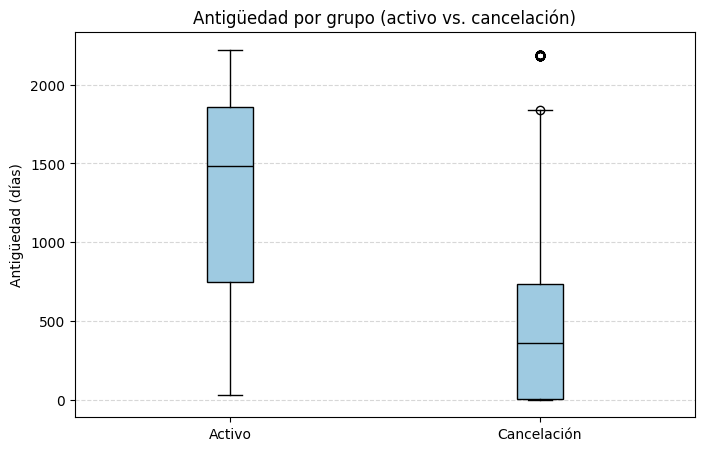

In [31]:
# Boxplot: antigüedad por grupo (activo vs. cancelación).
data_activo = contract.loc[~contract['Churn'], 'DaysActive']
data_churn  = contract.loc[ contract['Churn'], 'DaysActive']

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([data_activo, data_churn],
           tick_labels=['Activo', 'Cancelación'],
           patch_artist=True,
           boxprops=dict(facecolor='#9ecae1'),
           medianprops=dict(color='black'))
ax.set_ylabel('Antigüedad (días)')
ax.set_title('Antigüedad por grupo (activo vs. cancelación)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Lectura.** Los clientes activos llevan, en mediana, cerca del **doble de tiempo** con Interconnect que los clientes que cancelaron. La antigüedad, por sí sola, ya anticipa el riesgo de cancelación.


### 4.2 ¿Cómo se distribuye la antigüedad por tipo de contrato?

Se abre un panel por tipo de contrato para ver dónde se concentran las cancelaciones a lo largo de la antigüedad del cliente.

In [32]:
# Bins trimestrales y paleta por tipo de contrato.
bins = np.linspace(contract['DaysActive'].min(), contract['DaysActive'].max(), 25)

tipos = [
    ('Month-to-month', '#9ecae1', '#3182bd'),
    ('One year',       '#a1d99b', '#31a354'),
    ('Two year',       '#fdae6b', '#e6550d'),
]

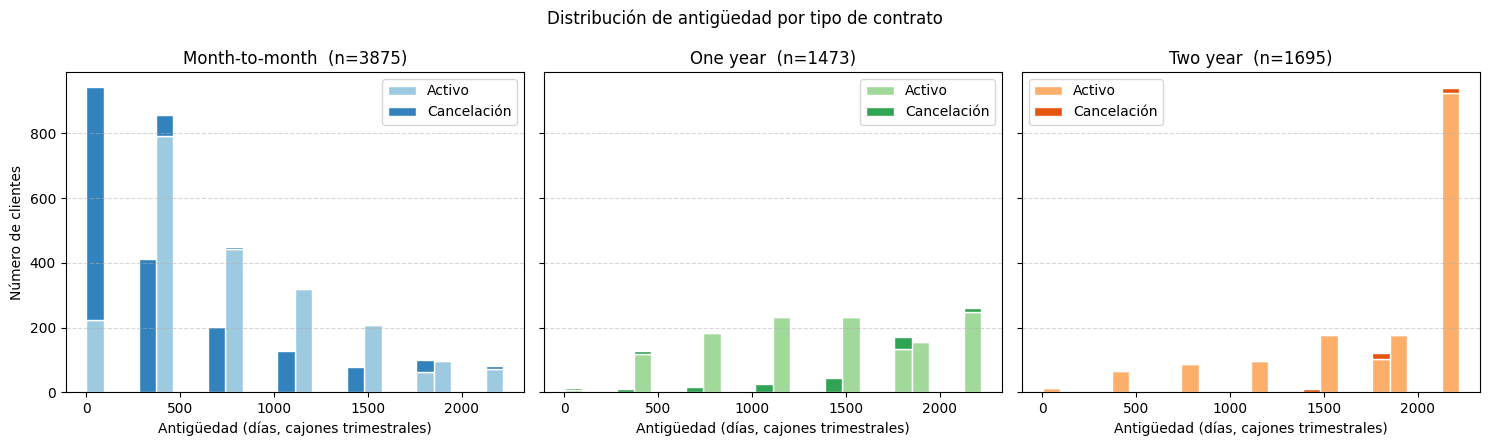

In [33]:
# Un subplot por tipo de contrato con barras apiladas (Activo / Cancelación).
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (tipo, color_activo, color_churn) in zip(axes, tipos):
    mask_tipo = contract['Type'] == tipo
    activos = contract.loc[mask_tipo & ~contract['Churn'], 'DaysActive']
    churn   = contract.loc[mask_tipo &  contract['Churn'], 'DaysActive']
    ax.hist([activos, churn],
            bins=bins, stacked=True,
            color=[color_activo, color_churn],
            edgecolor='white',
            label=['Activo', 'Cancelación'])
    ax.set_title(f'{tipo}  (n={int(mask_tipo.sum())})')
    ax.set_xlabel('Antigüedad (días, cajones trimestrales)')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend()

axes[0].set_ylabel('Número de clientes')
fig.suptitle('Distribución de antigüedad por tipo de contrato')
fig.tight_layout()
plt.show()

**Lectura.**

- **Month-to-month** (n = 3 875): distribución concentrada en los primeros meses; las cancelaciones dominan los primeros 300-400 días.
- **One year** (n = 1 473): distribución uniforme con cancelación mínima y constante.
- **Two year** (n = 1 695): distribución sesgada hacia la derecha (fecha de corte) y cancelación testimonial.

El tipo de contrato es el principal factor de riesgo. La cancelación se concentra en **Month-to-month** y en los **primeros meses** de relación.

### 4.3 ¿Cómo evolucionó la composición de la cartera por año de alta?

Agrupamos a los clientes por año de alta y tipo de contrato, distinguiendo entre quienes siguen activos y quienes cancelaron.

In [34]:
# Clientes por tipo de contrato, año de alta y estado final.
datos_anio = (contract
              .assign(_anio=contract['BeginDate'].dt.year)
              .groupby(['Type', '_anio', 'Churn'])
              .size()
              .unstack('Churn', fill_value=0)
              .rename(columns={False: 'Activo', True: 'Cancelación'}))

tipos = [
    ('Month-to-month', '#9ecae1', '#3182bd'),
    ('One year',       '#a1d99b', '#31a354'),
    ('Two year',       '#fdae6b', '#e6550d'),
]

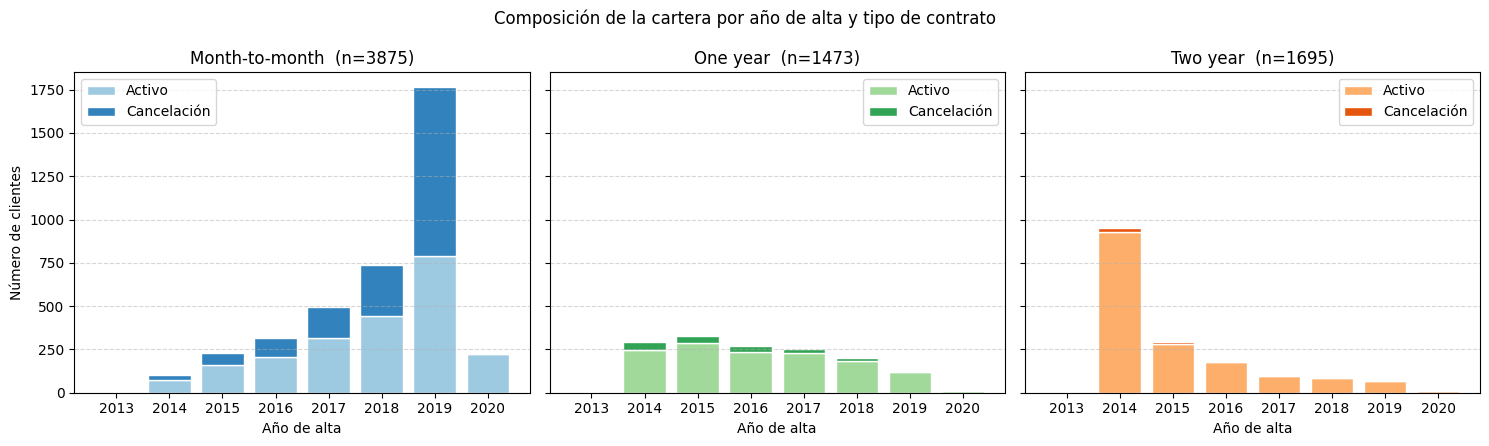

In [35]:
# Un subplot por tipo de contrato con barras apiladas por año.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (tipo, color_activo, color_churn) in zip(axes, tipos):
    sub = datos_anio.loc[tipo]
    ax.bar(sub.index, sub['Activo'], color=color_activo, edgecolor='white', label='Activo')
    ax.bar(sub.index, sub['Cancelación'], bottom=sub['Activo'],
           color=color_churn, edgecolor='white', label='Cancelación')
    ax.set_title(f'{tipo}  (n={int(sub.sum().sum())})')
    ax.set_xlabel('Año de alta')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend()

axes[0].set_ylabel('Número de clientes')
fig.suptitle('Composición de la cartera por año de alta y tipo de contrato')
fig.tight_layout()
plt.show()

**Lectura.** El crecimiento reciente se concentra en **Month-to-month**: los clientes que ingresaron en 2019 aportan la mayor parte de las cancelaciones. **Two year** está dominado por altas antiguas (2014) prácticamente sin fuga — son los clientes más leales de la cartera.

### 4.4 ¿Cómo evolucionó la tasa de cancelación por año y tipo de contrato?

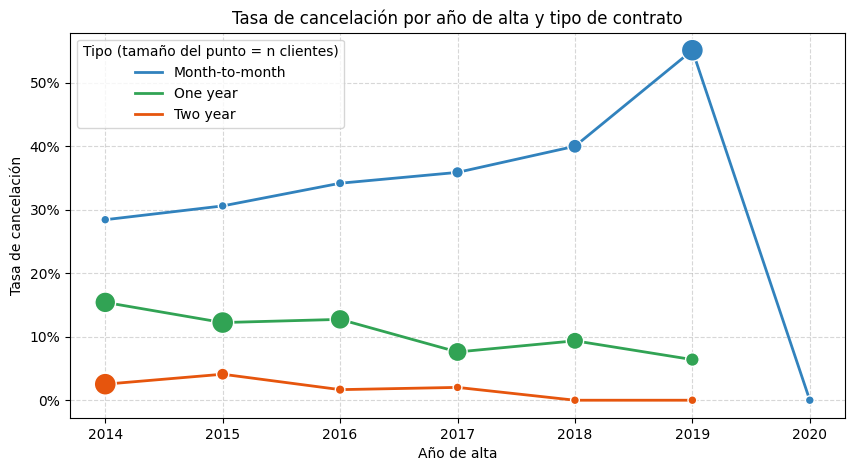

In [36]:
# Tasa de cancelación por año de alta y tipo de contrato.
# Agrupamos por cuándo entró el cliente, no por cuánto duró, para evitar el sesgo
# que introduce DaysActive (acoplado al propio Churn).
tasa_anual = (contract
                 .assign(_anio=contract['BeginDate'].dt.year)
                 .groupby(['Type', '_anio'], observed=True)['Churn']
                 .agg(tasa='mean', n='count')
                 .reset_index())

MIN_N = 30
tasa_anual = tasa_anual[tasa_anual['n'] >= MIN_N]

colores = {'Month-to-month': '#3182bd', 'One year': '#31a354', 'Two year': '#e6550d'}

fig, ax = plt.subplots(figsize=(10, 5))
for tipo in ['Month-to-month', 'One year', 'Two year']:
    sub = tasa_anual[tasa_anual['Type'] == tipo].sort_values('_anio')
    sizes = (sub['n'] / sub['n'].max() * 250).clip(lower=40)
    ax.plot(sub['_anio'], sub['tasa'], label=tipo, color=colores[tipo], linewidth=2, zorder=2)
    ax.scatter(sub['_anio'], sub['tasa'], s=sizes, color=colores[tipo], edgecolor='white', zorder=3)

ax.set_xlabel('Año de alta')
ax.set_ylabel('Tasa de cancelación')
ax.set_title('Tasa de cancelación por año de alta y tipo de contrato')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.grid(linestyle='--', alpha=0.5)
ax.legend(title='Tipo (tamaño del punto = n clientes)')
plt.show()

**Lectura.** En **Month-to-month** la tasa pasa del **28 % en 2014 al 55 % en 2019**: las cohortes recientes cancelan mucho más que las antiguas. **One year** y **Two year** se mantienen estables y bajas en todos los años. El 0 % aparente de 2020 corresponde a altas previas a la fecha de corte que aún no tuvieron oportunidad de cancelar.

## 5. Impacto económico de la cancelación

### 5.1 ¿Cuánto vale económicamente cada cliente?

Se construye el **LTV** (*Life Time Value*) como aproximación del valor económico acumulado: lo que cada cliente ha pagado durante su relación con la empresa.

In [37]:
# LTV (Life Time Value): valor económico acumulado por cliente.
# Fórmula: cargo mensual * meses activos (DaysActive / 30).
contract['LTV'] = contract['MonthlyCharges'] * (contract['DaysActive'] / 30)

tabla_ltv = (contract
             .groupby('Churn')['LTV']
             .describe()
             .round(2))
tabla_ltv.index = tabla_ltv.index.map({False: 'Activo', True: 'Cancelación'})
display(tabla_ltv)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
Activo,5174.0,2887.32,2448.23,19.43,877.38,1965.72,4771.45,8791.46
Cancelación,1869.0,1458.96,1881.26,0.63,8.83,868.27,2226.50,8603.33


### 5.2 ¿Cómo se distribuye el LTV entre activos y cancelados?

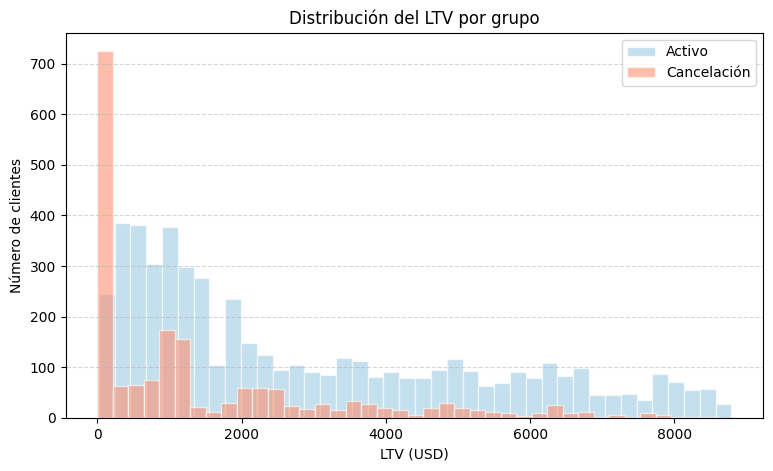

In [38]:
# Histograma del LTV por grupo.
ltv_activo = contract.loc[~contract['Churn'], 'LTV']
ltv_churn  = contract.loc[ contract['Churn'], 'LTV']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ltv_activo, bins=40, alpha=0.6, label='Activo',      color='#9ecae1', edgecolor='white')
ax.hist(ltv_churn,  bins=40, alpha=0.6, label='Cancelación', color='#fc9272', edgecolor='white')
ax.set_xlabel('LTV (USD)')
ax.set_ylabel('Número de clientes')
ax.set_title('Distribución del LTV por grupo')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Lectura.** Los clientes activos llegan a valores de LTV más altos que los cancelados. La cola larga a la derecha del grupo activo refleja la acumulación de cargos de quienes llevan varios años con la empresa; los cancelados se concentran en valores bajos porque su relación terminó antes.

### 5.3 ¿Cuánto dinero estamos perdiendo por cancelación?

In [39]:
# Agregados de LTV: total retenido, total perdido y desglose por tipo de contrato.
ltv_retenido = contract.loc[~contract['Churn'], 'LTV'].sum()
ltv_perdido  = contract.loc[ contract['Churn'], 'LTV'].sum()
ltv_total    = ltv_retenido + ltv_perdido

por_tipo = (contract
            .groupby(['Type', 'Churn'])['LTV'].sum()
            .unstack('Churn', fill_value=0)
            .rename(columns={False: 'Retenido', True: 'Perdido'})
            .loc[['Month-to-month', 'One year', 'Two year']])

In [40]:
# Paleta por tipo de contrato y formato monetario.
colores_tipo = {
    'Month-to-month': ('#9ecae1', '#3182bd'),
    'One year':       ('#a1d99b', '#31a354'),
    'Two year':       ('#fdae6b', '#e6550d'),
}

def fmt_money(y, _):
    if y >= 1e6: return f'${y/1e6:.1f}M'
    if y >= 1e3: return f'${y/1e3:.0f}k'
    return f'${y:.0f}'

Dos vistas: primero el total de la cartera (retenido vs perdido) y luego el mismo desglose abierto por tipo de contrato.

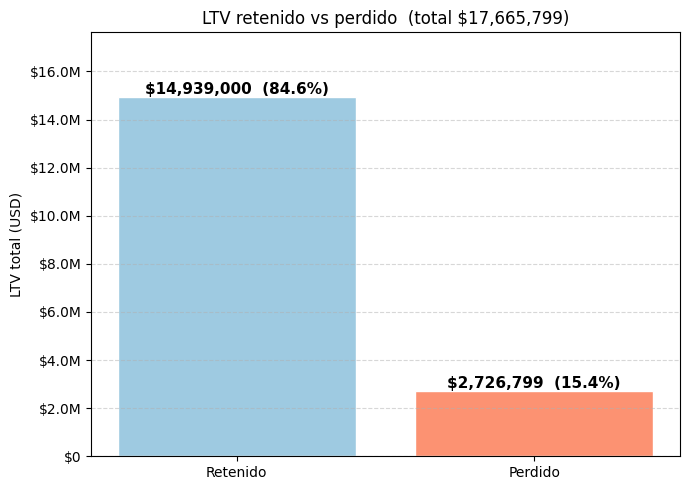

In [41]:
# Figura 1: LTV retenido vs perdido en el total de la cartera.
fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(['Retenido', 'Perdido'],
                [ltv_retenido, ltv_perdido],
                color=['#9ecae1', '#fc9272'], edgecolor='white')

for barra, valor in zip(barras, [ltv_retenido, ltv_perdido]):
    pct = valor / ltv_total * 100
    ax.text(barra.get_x() + barra.get_width() / 2, valor,
            f'${valor:,.0f}  ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('LTV total (USD)')
ax.set_title(f'LTV retenido vs perdido  (total ${ltv_total:,.0f})')
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_money))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(top=max(ltv_retenido, ltv_perdido) * 1.18)
fig.tight_layout()
plt.show()

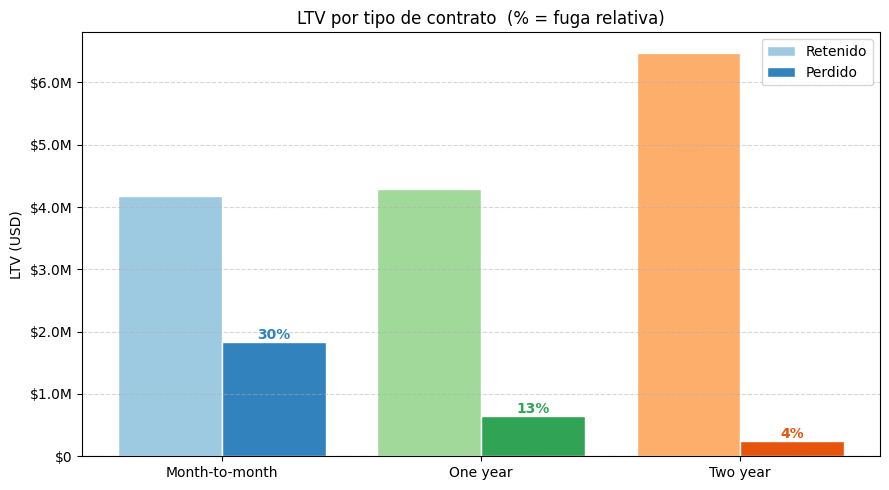

In [42]:
# Figura 2: LTV retenido vs perdido por tipo de contrato.
fig, ax = plt.subplots(figsize=(9, 5))
x = list(range(len(por_tipo)))
ancho = 0.4

for i, tipo in enumerate(por_tipo.index):
    color_claro, color_oscuro = colores_tipo[tipo]
    ret  = por_tipo.loc[tipo, 'Retenido']
    perd = por_tipo.loc[tipo, 'Perdido']
    ax.bar(i - ancho/2, ret,  width=ancho, color=color_claro,  edgecolor='white',
           label='Retenido' if i == 0 else None)
    ax.bar(i + ancho/2, perd, width=ancho, color=color_oscuro, edgecolor='white',
           label='Perdido'  if i == 0 else None)
    pct = perd / (ret + perd) * 100 if (ret + perd) > 0 else 0
    ax.text(i + ancho/2, perd, f'{pct:.0f}%',
            ha='center', va='bottom', fontsize=10, color=color_oscuro, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(por_tipo.index)
ax.set_ylabel('LTV (USD)')
ax.set_title('LTV por tipo de contrato  (% = fuga relativa)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_money))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()

In [43]:
# Tabla 1: LTV total retenido vs perdido
tabla_total = pd.DataFrame({
    'LTV':       [ltv_retenido, ltv_perdido, ltv_total],
    '% del LTV': [ltv_retenido/ltv_total*100,
                  ltv_perdido /ltv_total*100,
                  100.0],
}, index=['Retenido', 'Perdido', 'Total'])

tabla_total.style.format({'LTV': '${:,.0f}', '% del LTV': '{:.1f}%'})

,LTV,% del LTV
Retenido,"$14,939,000",84.6%
Perdido,"$2,726,799",15.4%
Total,"$17,665,799",100.0%


In [44]:
# Tabla 2: desglose por tipo de contrato.
tabla_tipo = por_tipo.copy()
tabla_tipo['Total']           = tabla_tipo['Retenido'] + tabla_tipo['Perdido']
tabla_tipo['% Fuga']          = tabla_tipo['Perdido'] / tabla_tipo['Total'] * 100
tabla_tipo['% del LTV total'] = tabla_tipo['Total']   / ltv_total * 100

tabla_tipo.style.format({
    'Retenido':        '${:,.0f}',
    'Perdido':         '${:,.0f}',
    'Total':           '${:,.0f}',
    '% Fuga':          '{:.1f}%',
    '% del LTV total': '{:.1f}%',
})

Churn,Retenido,Perdido,Total,% Fuga,% del LTV total
Type,,,,,
Month-to-month,"$4,172,230","$1,826,371","$5,998,601",30.4%,34.0%
One year,"$4,286,370","$647,246","$4,933,616",13.1%,27.9%
Two year,"$6,480,400","$253,182","$6,733,582",3.8%,38.1%


**Lectura.** Interconnect ha perdido aproximadamente **$2.7 M USD** por cancelación — un **15 % del LTV total**. La fuga se concentra en **Month-to-month** (**$1.8 M**, **30 %** de su segmento); las modalidades **One year** y **Two year** prácticamente no presentan fuga.

**Acción recomendada.** Priorizar la migración de clientes mensuales hacia contratos anuales o bianuales: es el segmento donde se concentra la pérdida y donde la oportunidad de recuperación es mayor.

## 6. ¿La diferencia entre activos y cancelados es estadísticamente real?

Se comparan dos muestras (activos y cancelados) en antigüedad con dos pruebas: Mann-Whitney (no paramétrica, principal) y Welch (apoyo, sobre medias). Se reporta además el tamaño del efecto.

In [45]:
# Separación de las dos muestras.
activos = contract.loc[~contract['Churn'], 'DaysActive']
churned = contract.loc[ contract['Churn'], 'DaysActive']

if pd.api.types.is_timedelta64_dtype(activos):
    activos = activos.dt.days
    churned = churned.dt.days

print(f'Activos  n={len(activos):>5}  media={activos.mean():7.1f}  mediana={activos.median():7.1f}')
print(f'Canceló  n={len(churned):>5}  media={churned.mean():7.1f}  mediana={churned.median():7.1f}')

Activos  n= 5174  media= 1291.8  mediana= 1481.0
Canceló  n= 1869  media=  516.4  mediana=  360.0


In [46]:
# Mann-Whitney U (no paramétrica, principal).
u_stat, p_mw = stats.mannwhitneyu(activos, churned, alternative='two-sided')
print(f'Mann-Whitney U = {u_stat:,.0f}   p-value = {p_mw:.3e}')

# Welch t-test (apoyo, sobre medias).
t_stat, p_t = stats.ttest_ind(activos, churned, equal_var=False)
print(f'Welch t-test    t = {t_stat:7.3f}   p-value = {p_t:.3e}')

# Tamaño de efecto rank-biserial (derivado de U).
n1, n2 = len(activos), len(churned)
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f'Rank-biserial r = {r_rb:+.3f}')

Mann-Whitney U = 8,184,410   p-value = 0.000e+00
Welch t-test    t =  45.774   p-value = 0.000e+00
Rank-biserial r = -0.693


In [47]:
# Decisión al nivel de significancia habitual.
alpha = 0.05
if p_mw < alpha:
    print(f'Rechazamos H0 (p={p_mw:.2e} < {alpha}):')
    print('La antigüedad difiere entre clientes activos y los que cancelaron.')
else:
    print(f'No rechazamos H0 (p={p_mw:.2e} >= {alpha}):')
    print('Sin evidencia de diferencia en antigüedad.')

Rechazamos H0 (p=0.00e+00 < 0.05):
La antigüedad difiere entre clientes activos y los que cancelaron.


**Lectura.** La prueba estadistica arroja un **p-value practicamente en cero**, muy por debajo del umbral habitual de 0.05. Traducido al negocio: la diferencia de antiguedad entre clientes activos y los que cancelaron **no es casualidad**; es un patron real y consistente en la poblacion. Por eso podemos apoyar la estrategia de retencion en la variable `DaysActive` con confianza.

## 7. Tabla unificada para el modelado

Se consolidan las cuatro tablas en un único `DataFrame` con *left join* desde `contract`, que preserva a todos los clientes. Los clientes sin servicio de internet o teléfono aparecerán con nulos en esas columnas; se codifican como *sin servicio* en el siguiente paso.

In [48]:
# Unión de las cuatro tablas por CustomerID (left desde contract).
df = (contract
      .merge(personal, on='CustomerID', how='left')
      .merge(internet, on='CustomerID', how='left')
      .merge(phone,    on='CustomerID', how='left'))

### Auditoria de nulos post-merge

Tras unir las cuatro tablas y aplicar el feature engineering, revisamos el inventario de valores faltantes. Es la foto que entra al modelo.

In [49]:
# Inventario de nulos por columna tras el merge completo.
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

print(f"Filas totales en df: {len(df)}")
print(f"Columnas con nulos: {len(nulos)}")
if len(nulos) > 0:
    print()
    tabla_nulos = pd.DataFrame({
        "nulos": nulos,
        "porcentaje": (nulos / len(df) * 100).round(2),
        "razon_probable": [
            "Clientes sin servicio de internet" if any(x in col for x in
                ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"])
            else "Clientes sin servicio de telefono" if col == "MultipleLines"
            else "Clientes sin servicio de internet" if col == "InternetService"
            else "Clientes nuevos sin historial" if col == "TotalCharges"
            else "(revisar)"
            for col in nulos.index
        ],
    })
    print(tabla_nulos.to_string())
else:
    print("No hay columnas con nulos.")

# Comprobacion: los 'nulos' de internet/telefono son expected (el cliente simplemente
# no contrato ese servicio, no son datos perdidos). Se tratan en la seccion de
# preparacion con fillna(False) o fillna('Sin servicio').

Filas totales en df: 7043
Columnas con nulos: 9

                  nulos  porcentaje                     razon_probable
InternetService    1526       21.67  Clientes sin servicio de internet
TechSupport        1526       21.67  Clientes sin servicio de internet
OnlineSecurity     1526       21.67  Clientes sin servicio de internet
OnlineBackup       1526       21.67  Clientes sin servicio de internet
DeviceProtection   1526       21.67  Clientes sin servicio de internet
StreamingMovies    1526       21.67  Clientes sin servicio de internet
StreamingTV        1526       21.67  Clientes sin servicio de internet
MultipleLines       682        9.68  Clientes sin servicio de telefono
TotalCharges         11        0.16      Clientes nuevos sin historial


**Lectura.** Los nulos que aparecen **no son datos perdidos**, son clientes que simplemente no contrataron ese servicio. Las columnas de internet (`OnlineSecurity`, `OnlineBackup`, etc.) estan vacias para clientes sin servicio de internet; `MultipleLines` para clientes sin telefono. Se rellenan con `False` (no tiene el servicio) o con la etiqueta `'Sin servicio'` en `InternetService`. El unico caso de "dato realmente faltante" fue `TotalCharges` para 11 clientes recien dados de alta, resuelto al convertir a numerico (`NaN`) y luego excluir la variable por redundancia.

In [50]:
# Verificación de la tabla unificada.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   Churn             7043 non-null   bool          
 9   DaysActive        7043 non-null   int64         
 10  Tenure            7043 non-null   int64         
 11  Automatic         7043 non-null   bool          
 12  DaysActiveGroup   7043 non-null   category      
 13  LTV               7043 non-null   float64       
 14  Gender            7043 n

Al unir aparecen nulos: 5 517 clientes en internet y 6 361 en teléfono, frente a 7 043 en contrato. No son datos faltantes: son clientes que no contrataron ese servicio. Se codifica explícitamente.

In [51]:
# Columnas booleanas y categóricas a revisar y preparar para el modelo.
cols_bol_cat = [
    'PaperlessBilling', 'PaymentMethod', 'Churn', 'Automatic',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'Gender', 'Partner', 'SeniorCitizen',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines',
]

def value_counts_cols(df, cols):
    for col in cols:
        print(df[col].value_counts(normalize=True))
        print()

In [52]:
# Clientes sin internet/teléfono: los nulos representan servicios no contratados.
# Se rellenan con 'False' (literal) para convertirlos a booleano en el siguiente paso.
cols_rellenar = [
    'PaperlessBilling', 'SeniorCitizen', 'OnlineSecurity', 'OnlineBackup',
    'Partner', 'Dependents', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'MultipleLines',
]
df[cols_rellenar] = df[cols_rellenar].fillna('False').infer_objects(copy=False)

En `InternetService`, los nulos se rellenan con la etiqueta *Sin servicio*: son clientes que no contrataron internet, no registros incompletos.

In [53]:
# En InternetService, los nulos corresponden a clientes sin servicio contratado.
df['InternetService'] = df['InternetService'].fillna('Sin servicio')
print(df['InternetService'].unique())

['DSL' 'Fiber optic' 'Sin servicio']


In [54]:
# Conversión a booleano real de las columnas con texto Yes/No/True/False.
str_to_bool(df, cols_rellenar)

,CustomerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,DaysActive,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,5248-YGIJN,2014-01-02,2020-02-01,Two year,True,Credit card (automatic),90.25,6369.45,False,2221,...,True,False,DSL,True,True,True,True,True,True,True
1,6234-RAAPL,2014-01-02,2020-02-01,Two year,False,Bank transfer (automatic),99.90,7251.70,False,2221,...,True,True,Fiber optic,True,True,False,True,True,False,True
2,5954-BDFSG,2014-01-02,2020-02-01,Two year,True,Credit card (automatic),107.50,7853.70,False,2221,...,False,False,Fiber optic,False,False,True,True,True,True,True
3,0526-SXDJP,2014-01-02,2020-02-01,Two year,False,Bank transfer (automatic),42.10,2962.00,False,2221,...,True,False,DSL,True,True,True,False,False,False,False
4,9848-JQJTX,2014-01-02,2020-02-01,Two year,True,Bank transfer (automatic),100.90,7459.05,False,2221,...,False,False,Fiber optic,False,True,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0616-ATFGB,2019-01-09,2019-01-10,Month-to-month,False,Electronic check,25.05,25.05,True,1,...,True,False,DSL,False,False,False,False,False,False,False
7039,5909-ECHUI,2019-01-09,2019-01-10,Month-to-month,True,Electronic check,56.25,56.25,True,1,...,False,False,DSL,False,False,False,False,False,True,False
7040,1062-LHZOD,2019-01-09,2019-01-10,Month-to-month,True,Mailed check,69.90,69.90,True,1,...,True,True,Fiber optic,False,False,False,False,False,False,False
7041,9248-OJYKK,2019-01-09,2019-01-10,Month-to-month,True,Electronic check,76.45,76.45,True,1,...,False,False,Fiber optic,False,False,False,False,False,False,True


In [55]:
# Verificación de tipos finales.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   bool          
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7032 non-null   float64       
 8   Churn             7043 non-null   bool          
 9   DaysActive        7043 non-null   int64         
 10  Tenure            7043 non-null   int64         
 11  Automatic         7043 non-null   bool          
 12  DaysActiveGroup   7043 non-null   category      
 13  LTV               7043 non-null   float64       
 14  Gender            7043 n

In [56]:
# Distribuciones por columna booleana/categórica (apoyo para validar la preparación).
value_counts_cols(df, cols_bol_cat)

PaperlessBilling
True     0.592219
False    0.407781
Name: proportion, dtype: float64

PaymentMethod
Electronic check             0.335794
Mailed check                 0.228880
Bank transfer (automatic)    0.219225
Credit card (automatic)      0.216101
Name: proportion, dtype: float64

Churn
False    0.73463
True     0.26537
Name: proportion, dtype: float64

Automatic
False    0.564674
True     0.435326
Name: proportion, dtype: float64

InternetService
Fiber optic     0.439585
DSL             0.343746
Sin servicio    0.216669
Name: proportion, dtype: float64

OnlineSecurity
False    0.713332
True     0.286668
Name: proportion, dtype: float64

OnlineBackup
False    0.655119
True     0.344881
Name: proportion, dtype: float64

Gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64

Partner
False    0.516967
True     0.483033
Name: proportion, dtype: float64

SeniorCitizen
False    0.837853
True     0.162147
Name: proportion, dtype: float64

DeviceProtection
False   

In [57]:
# Distribución de la variable objetivo (desbalance de clases).
df['Churn'].value_counts(normalize=True)

Churn
False    0.73463
True     0.26537
Name: proportion, dtype: float64

In [58]:
# Seleccion final de columnas para el modelado.
# Tenure sustituye a DaysActive (anchor uniforme, sin fuga).
# TotalCharges y LTV descartadas por redundancia / fuga.
cols_modelado = [
    'CustomerID', 'Type', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'Churn', 'Automatic', 'Tenure',
    'Gender', 'SeniorCitizen', 'Partner',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'MultipleLines',
]
df_modelado = df[cols_modelado].copy()

# Feature engineering minimo y honesto (solo combinaciones que no son colineales):
# AddonsCount: numero de servicios de valor agregado contratados (seguridad, respaldo, soporte,
#              device protection). Clientes mas "equipados" cancelan menos.
addons_bool = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_modelado['AddonsCount'] = df_modelado[addons_bool].sum(axis=1)

# FiberNoSecurity: interaccion clasica del dataset Telco. Fibra optica (servicio premium)
# sin seguridad online es un segmento de alto riesgo observado en la industria.
df_modelado['FiberNoSecurity'] = (
    (df_modelado['InternetService'] == 'Fiber optic') &
    (~df_modelado['OnlineSecurity'].astype(bool))
).astype(int)

df_modelado.head()

,CustomerID,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Automatic,Tenure,Gender,SeniorCitizen,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,AddonsCount,FiberNoSecurity
0,5248-YGIJN,Two year,True,Credit card (automatic),90.25,False,True,2221,Male,False,...,DSL,True,True,True,True,True,True,True,4,0
1,6234-RAAPL,Two year,False,Bank transfer (automatic),99.90,False,True,2221,Female,False,...,Fiber optic,True,True,False,True,True,False,True,3,0
2,5954-BDFSG,Two year,True,Credit card (automatic),107.50,False,True,2221,Female,False,...,Fiber optic,False,False,True,True,True,True,True,2,1
3,0526-SXDJP,Two year,False,Bank transfer (automatic),42.10,False,True,2221,Male,False,...,DSL,True,True,True,False,False,False,False,3,0
4,9848-JQJTX,Two year,True,Bank transfer (automatic),100.90,False,True,2221,Male,False,...,Fiber optic,False,True,True,False,True,True,True,2,1


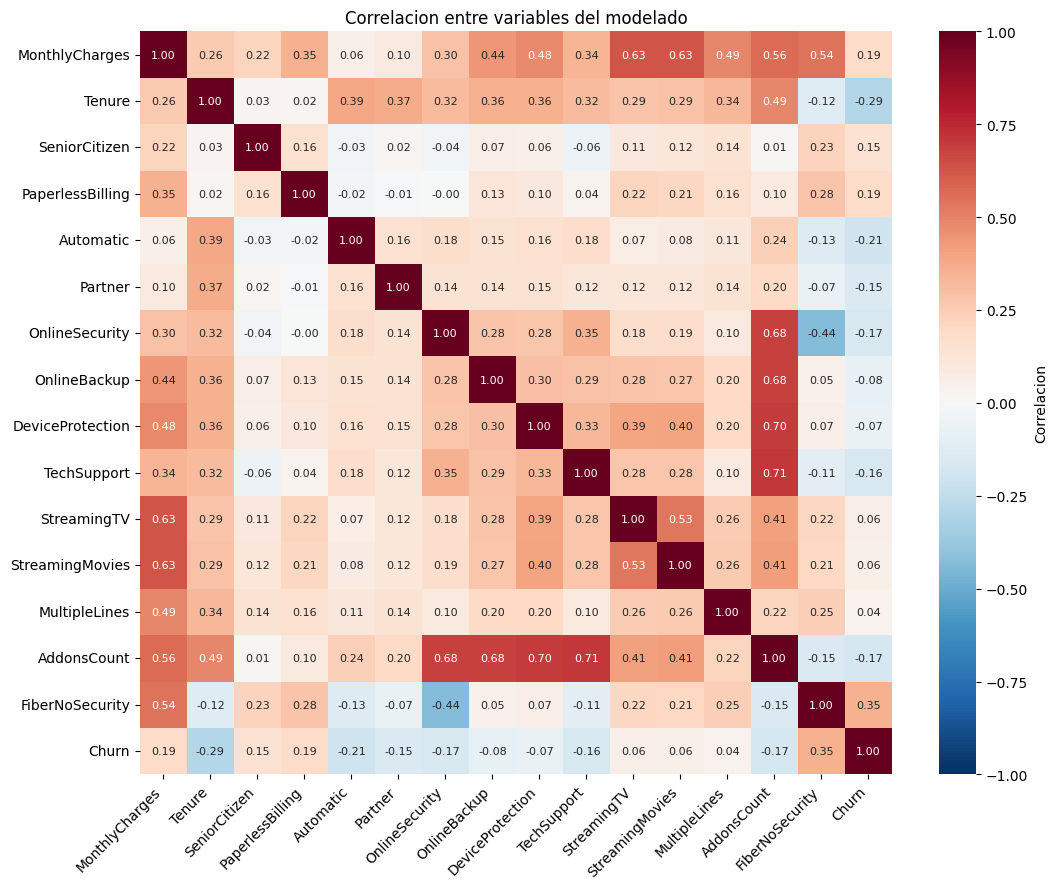

In [59]:
# Matriz de correlaciones sobre el set de modelado.
cols_corr = [
    'MonthlyCharges', 'Tenure', 'SeniorCitizen',
    'PaperlessBilling', 'Automatic', 'Partner',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'MultipleLines',
    'AddonsCount', 'FiberNoSecurity',
    'Churn',
]
corr = df_modelado[cols_corr].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlacion'}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlacion entre variables del modelado')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
fig.tight_layout()
plt.show()

**Lectura.** `Tenure` (tiempo como cliente) es la variable mas relacionada con cancelacion: negativa y la mas fuerte. Le siguen `Automatic` (pago automatico) y los servicios de valor agregado (`OnlineSecurity`, `TechSupport`) como frenos. `PaperlessBilling` y `MonthlyCharges` empujan al alza. Los numeros van de -1 a +1; por encima de 0.3 la relacion se considera relevante para negocio.

In [60]:
# VIF (Variance Inflation Factor): diagnostico de multicolinealidad.
# VIF_i = diagonal de la inversa de la matriz de correlacion. <5 OK, 5-10 vigilar, >10 grave.
X_vif = df_modelado[cols_corr].drop(columns='Churn').astype(float)
vif = (pd.DataFrame({
            'feature': X_vif.columns,
            'VIF': np.diag(np.linalg.inv(X_vif.corr())).round(2),
        })
        .sort_values('VIF', ascending=False)
        .reset_index(drop=True))
vif

,feature,VIF
0,MonthlyCharges,8.620000e+00
1,FiberNoSecurity,4.310000e+00
2,StreamingTV,1.940000e+00
3,StreamingMovies,1.930000e+00
4,Tenure,1.800000e+00
5,MultipleLines,1.550000e+00
6,Automatic,1.190000e+00
7,PaperlessBilling,1.170000e+00
8,Partner,1.160000e+00
9,SeniorCitizen,1.090000e+00


**Lectura.** Medimos la **redundancia entre variables** con un indicador tecnico llamado VIF. Regla practica: valores por debajo de 5 indican variables "sanas" (cada una aporta informacion propia); por encima de 10 hay redundancia grave. En nuestro caso todos quedan bajo 5, asi que el modelo puede usarlas todas sin confusion. Haber descartado antes `TotalCharges` y `LTV` hizo su trabajo.

**Funcion de evaluacion.** Para cada modelo mostramos F1 vs umbral, curva ROC y curva PRC, mas una tabla con Accuracy, F1, APS y ROC AUC en train/test. Las X naranja marcan umbrales de referencia (0.2, 0.4, 0.6, 0.8) y la X roja el 0.5 por defecto.

In [61]:
# Funcion de evaluacion comun: F1 vs umbral, curva ROC y PRC, ademas de Accuracy/F1/APS/ROC AUC.
# Se reutiliza en cada modelo con predict_proba.
def evaluate_model(model, train_features, train_target, test_features, test_target):
    """Genera graficos de F1 vs umbral, curva ROC y curva PRC."""
    eval_stats = {}
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for tipo, features, target in (
        ('train', train_features, train_target),
        ('test', test_features, test_target)
    ):
        eval_stats[tipo] = {}
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba >= th) for th in f1_thresholds]

        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[tipo]['ROC AUC'] = roc_auc

        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[tipo]['APS'] = aps

        color = 'blue' if tipo == 'train' else 'green'

        ax = axs[0]
        max_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color,
                label=f'{tipo}, max={f1_scores[max_idx]:.2f} @ {f1_thresholds[max_idx]:.2f}')
        for th in (0.2, 0.4, 0.5, 0.6, 0.8):
            idx = np.argmin(np.abs(f1_thresholds - th))
            mc = 'red' if th == 0.5 else 'orange'
            ax.plot(f1_thresholds[idx], f1_scores[idx], color=mc, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('Umbral'); ax.set_ylabel('F1')
        ax.legend(loc='lower center'); ax.set_title('F1 vs Umbral')

        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{tipo}, ROC AUC={roc_auc:.2f}')
        for th in (0.2, 0.4, 0.5, 0.6, 0.8):
            idx = np.argmin(np.abs(roc_thresholds - th))
            mc = 'red' if th == 0.5 else 'orange'
            ax.plot(fpr[idx], tpr[idx], color=mc, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.legend(loc='lower center'); ax.set_title('Curva ROC')

        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{tipo}, AP={aps:.2f}')
        for th in (0.2, 0.4, 0.5, 0.6, 0.8):
            idx = np.argmin(np.abs(pr_thresholds - th))
            mc = 'red' if th == 0.5 else 'orange'
            ax.plot(recall[idx], precision[idx], color=mc, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.legend(loc='lower center'); ax.set_title('Curva PRC')

        eval_stats[tipo]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[tipo]['F1'] = metrics.f1_score(target, pred_target)

    df_eval = pd.DataFrame(eval_stats).round(4)
    df_eval = df_eval.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    print(df_eval)
    fig.tight_layout()
    return df_eval

In [62]:
# Preparacion: one-hot en categoricas, upsampling solo en train, CV sobre train crudo.
# 2 features derivadas anadidas (AddonsCount, FiberNoSecurity).
cat_cols = ["Type", "PaymentMethod", "InternetService", "Gender"]
bool_cols = ["PaperlessBilling", "Automatic", "SeniorCitizen", "Partner",
             "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
             "StreamingTV", "StreamingMovies", "MultipleLines", "FiberNoSecurity"]
num_cols = ["MonthlyCharges", "Tenure", "AddonsCount"]

X = pd.get_dummies(
    df_modelado[num_cols + bool_cols + cat_cols],
    columns=cat_cols, drop_first=True, dtype=float,
).astype(float)
y = df_modelado["Churn"].astype(int)

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_SEED
)

train = pd.concat([X_train_raw, y_train_raw.rename("Churn")], axis=1)
maj = train[train["Churn"] == 0]
minn = train[train["Churn"] == 1]
min_up = minn.sample(n=len(maj), replace=True, random_state=RANDOM_SEED)
train_bal = pd.concat([maj, min_up]).sample(frac=1, random_state=RANDOM_SEED)
X_train = train_bal.drop(columns="Churn").reset_index(drop=True)
y_train = train_bal["Churn"].reset_index(drop=True)

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f"Clientes totales: {len(df_modelado)}  |  features tras one-hot: {X.shape[1]}")
print(f"Features derivadas anadidas: AddonsCount (numerica) + FiberNoSecurity (booleana)")
print(f"Train crudo (CV): {len(X_train_raw)}  |  Train upsampled (fit): {len(X_train)}")
print(f"Test (evaluacion): {len(X_test)} con distribucion original {y_test.value_counts().to_dict()}")

Clientes totales: 7043  |  features tras one-hot: 23
Features derivadas anadidas: AddonsCount (numerica) + FiberNoSecurity (booleana)
Train crudo (CV): 5282  |  Train upsampled (fit): 7760
Test (evaluacion): 1761 con distribucion original {0: 1294, 1: 467}


           train    test
Accuracy  0.5138  0.5065
F1        0.5150  0.3432
APS       0.5071  0.2652
ROC AUC   0.5138  0.5000


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.5,0.0004,0.0003,0.0006


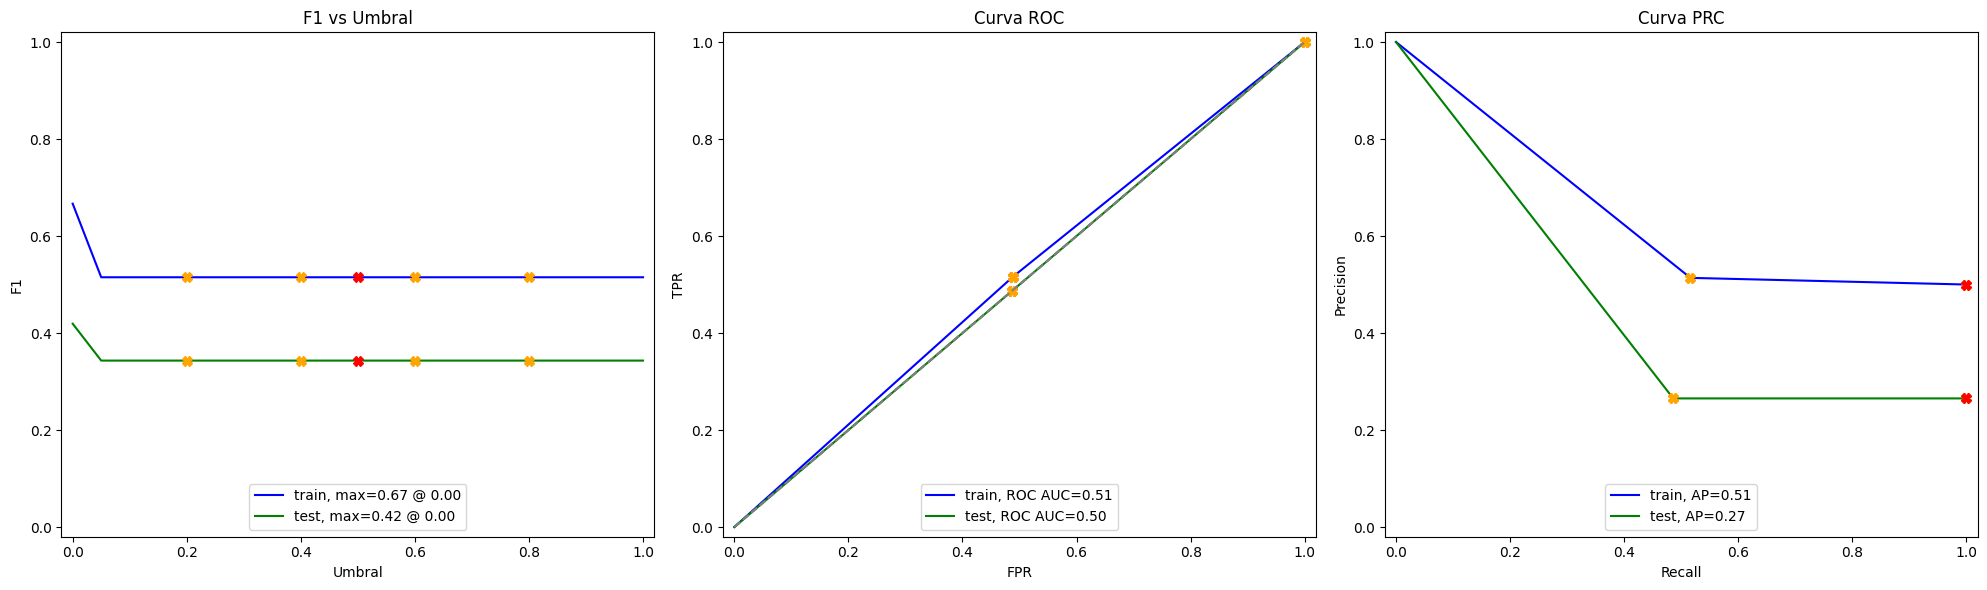

In [63]:
# Linea base: el cliente medio tirando una moneda ponderada.
# Sin CV porque no hay que estimar nada (predice al azar por diseno).
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)

t0 = time.perf_counter()
dummy.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]
t_pred = time.perf_counter() - t0

auc_dummy = roc_auc_score(y_test, y_proba_dummy)

resultados_modelos = pd.DataFrame([{
    "modelo": "DummyClassifier",
    "CV_AUC_mean": np.nan,
    "CV_AUC_std": np.nan,
    "AUC-ROC": round(auc_dummy, 3),
    "tiempo_fit_s": round(t_fit, 4),
    "tiempo_pred_s": round(t_pred, 4),
    "tiempo_total_s": round(t_fit + t_pred, 4),
}])
evaluate_model(dummy, X_train, y_train, X_test, y_test)
resultados_modelos

**Estrategia de balanceo y validacion.** La variable objetivo `Churn` esta desbalanceada (73.5 % activos vs 26.5 % cancelados). Aplicamos **upsampling** solo al train (replicar la clase minoritaria con reemplazo hasta igualar a la mayoritaria) para que el modelo no aprenda a decir "no cancela" siempre. El test se mantiene con la distribucion original para que las metricas reflejen el comportamiento real. La **validacion cruzada**, en cambio, se hace sobre el train **crudo** (sin replicar) con un ajuste temporal de pesos: asi evitamos que un mismo cliente aparezca duplicado en train y validacion al mismo tiempo.

CV AUC (5-fold, raw): 0.827 +/- 0.012  |  AUC-ROC test: 0.822
           train    test
Accuracy  0.7823  0.7252
F1        0.7938  0.5973
APS       0.8224  0.5814
ROC AUC   0.8626  0.8216


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.500,0.0004,0.0003,0.0006
1,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137


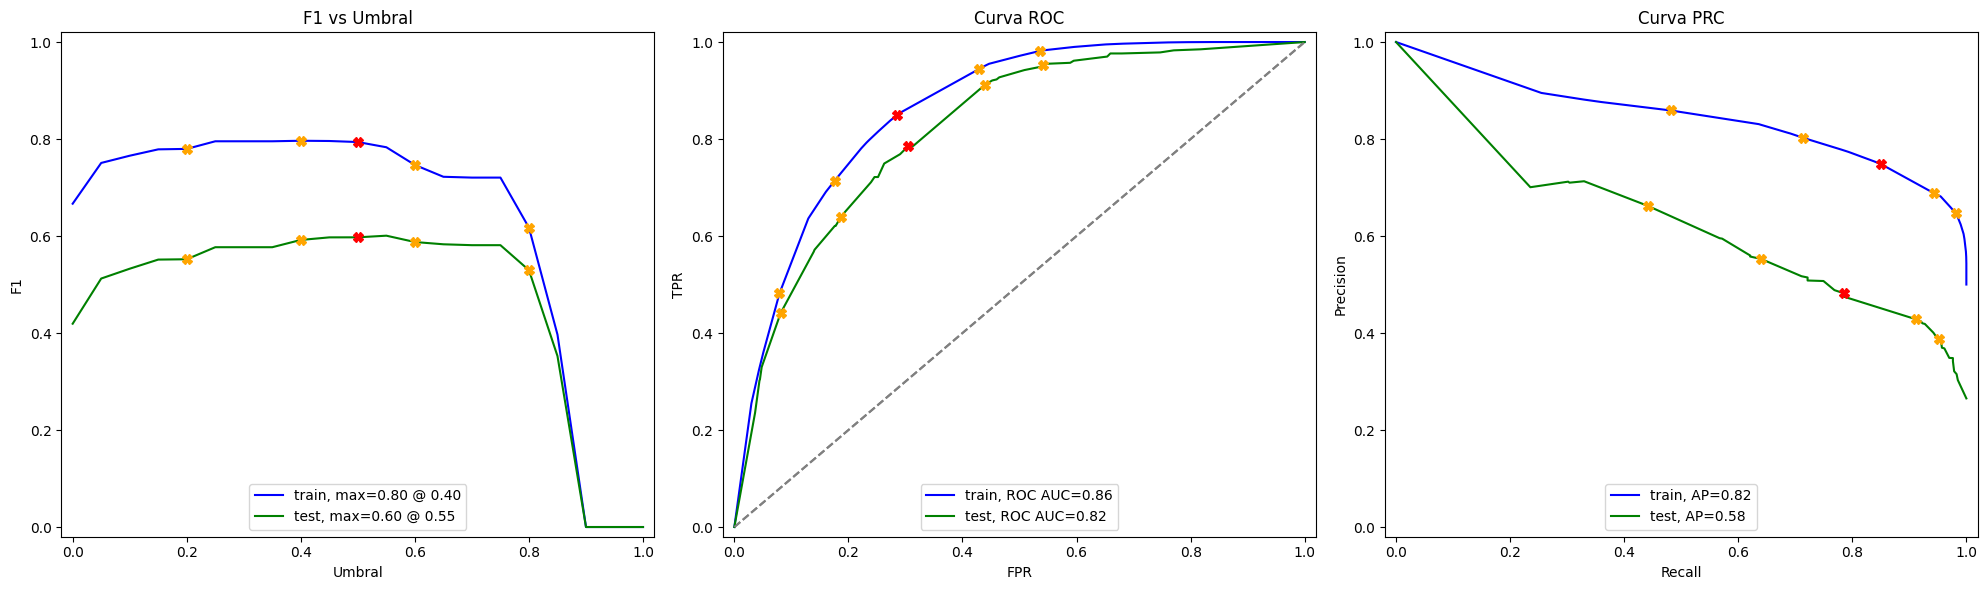

In [64]:
# Arbol de decision: el modelo mas simple e interpretable del lineup.
# CV sobre train crudo (sin upsampling) con class_weight="balanced" temporal para evitar fugas.
dtree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
)

cv_model = clone(dtree).set_params(class_weight="balanced")
cv_scores = cross_val_score(cv_model, X_train_raw, y_train_raw, cv=cv_folds,
                            scoring="roc_auc", n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

t0 = time.perf_counter()
dtree.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba = dtree.predict_proba(X_test)[:, 1]
t_pred = time.perf_counter() - t0

auc = roc_auc_score(y_test, y_proba)

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": "DecisionTree",
        "CV_AUC_mean": round(cv_mean, 3),
        "CV_AUC_std": round(cv_std, 3),
        "AUC-ROC": round(auc, 3),
        "tiempo_fit_s": round(t_fit, 4),
        "tiempo_pred_s": round(t_pred, 4),
        "tiempo_total_s": round(t_fit + t_pred, 4),
    }]),
], ignore_index=True)
print(f"CV AUC (5-fold, raw): {cv_mean:.3f} +/- {cv_std:.3f}  |  AUC-ROC test: {auc:.3f}")
evaluate_model(dtree, X_train, y_train, X_test, y_test)
resultados_modelos

**Arbol de decision.** Modelo no lineal mas simple del lineup. Sirve como puente entre el baseline y los ensembles: si un solo arbol acotado ya saca ventaja sobre Dummy, confirma que los features tienen senal. Los ensembles posteriores deberian mejorarlo.

CV AUC (5-fold, raw): 0.833 +/- 0.012  |  AUC-ROC test: 0.825
           train    test
Accuracy  0.7582  0.7354
F1        0.7680  0.6130
APS       0.8081  0.6025
ROC AUC   0.8361  0.8250


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.500,0.0004,0.0003,0.0006
1,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137
2,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155


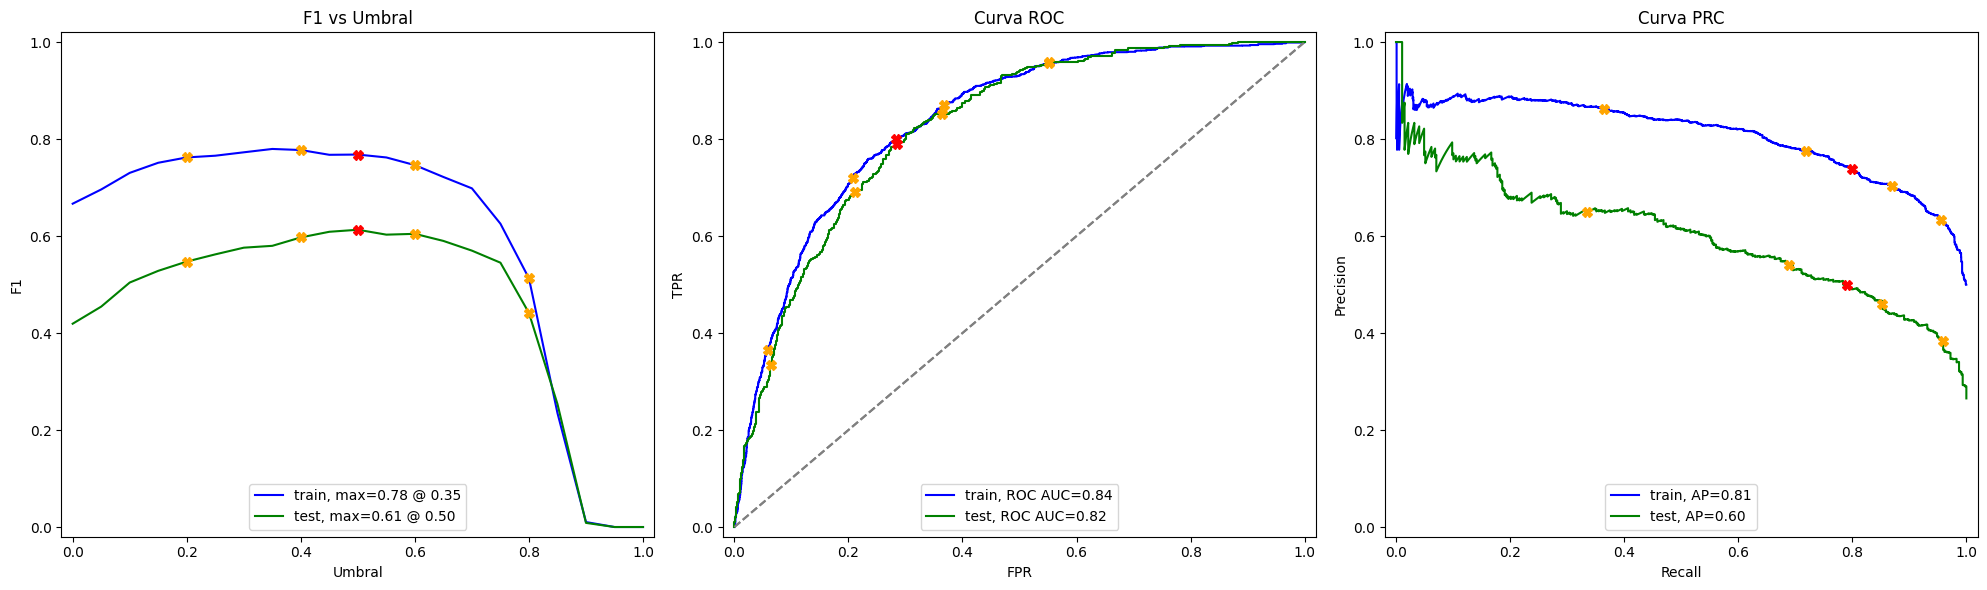

In [65]:
# Regresion logistica escalada: referencia lineal interpretable.
# CV sobre train crudo (sin upsampling) con class_weight="balanced" temporal para evitar fugas.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

cv_model = clone(logreg)
cv_model.set_params(clf__class_weight="balanced")
cv_scores = cross_val_score(cv_model, X_train_raw, y_train_raw, cv=cv_folds,
                            scoring="roc_auc", n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

t0 = time.perf_counter()
logreg.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba = logreg.predict_proba(X_test)[:, 1]
t_pred = time.perf_counter() - t0

auc = roc_auc_score(y_test, y_proba)

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": "LogisticRegression",
        "CV_AUC_mean": round(cv_mean, 3),
        "CV_AUC_std": round(cv_std, 3),
        "AUC-ROC": round(auc, 3),
        "tiempo_fit_s": round(t_fit, 4),
        "tiempo_pred_s": round(t_pred, 4),
        "tiempo_total_s": round(t_fit + t_pred, 4),
    }]),
], ignore_index=True)
print(f"CV AUC (5-fold, raw): {cv_mean:.3f} +/- {cv_std:.3f}  |  AUC-ROC test: {auc:.3f}")
evaluate_model(logreg, X_train, y_train, X_test, y_test)
resultados_modelos

**Regresion logistica.** Modelo lineal con escalado previo. Es la referencia interpretable: sus coeficientes indican la direccion e intensidad de cada feature. Sirve para contrastar si los modelos no-lineales (RF, XGB, LGBM) aportan ganancia real.

CV AUC (5-fold, raw): 0.849 +/- 0.008  |  AUC-ROC test: 0.838


           train    test
Accuracy  0.8631  0.7672
F1        0.8692  0.6232
APS       0.9164  0.6345
ROC AUC   0.9313  0.8382


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.500,0.0004,0.0003,0.0006
1,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137
2,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155
3,RandomForest,0.849,0.008,0.838,0.4095,0.0720,0.4815


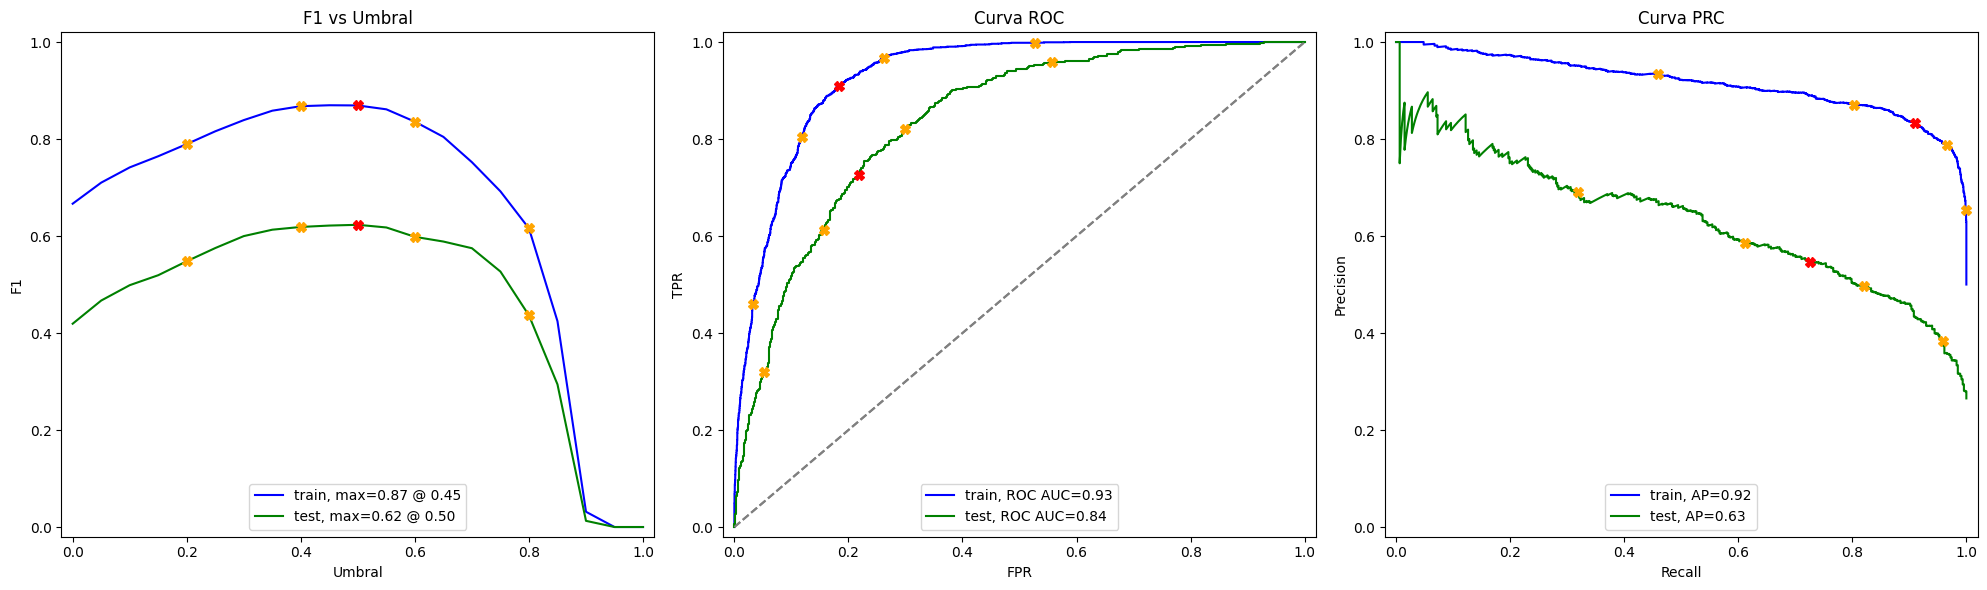

In [66]:
# Random Forest: ensemble de arboles votando en paralelo.
# CV sobre train crudo (sin upsampling) con class_weight="balanced" temporal para evitar fugas.
# max_depth=10 y min_samples_leaf=5 acotan el riesgo de sobreajuste.
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

cv_model = clone(rf).set_params(class_weight="balanced")
cv_scores = cross_val_score(cv_model, X_train_raw, y_train_raw, cv=cv_folds,
                            scoring="roc_auc", n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

t0 = time.perf_counter()
rf.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba = rf.predict_proba(X_test)[:, 1]
t_pred = time.perf_counter() - t0

auc = roc_auc_score(y_test, y_proba)

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": "RandomForest",
        "CV_AUC_mean": round(cv_mean, 3),
        "CV_AUC_std": round(cv_std, 3),
        "AUC-ROC": round(auc, 3),
        "tiempo_fit_s": round(t_fit, 4),
        "tiempo_pred_s": round(t_pred, 4),
        "tiempo_total_s": round(t_fit + t_pred, 4),
    }]),
], ignore_index=True)
print(f"CV AUC (5-fold, raw): {cv_mean:.3f} +/- {cv_std:.3f}  |  AUC-ROC test: {auc:.3f}")
evaluate_model(rf, X_train, y_train, X_test, y_test)
resultados_modelos

**Random Forest.** Combina muchos arboles de decision entrenados sobre submuestras distintas y promedia sus votos. Con `max_depth=10` y `min_samples_leaf=5` evitamos que cada arbol memorice el train. Sobre el train balanceado por upsampling, supera con holgura al baseline. Mas lento que los boosting modernos, pero sencillo de explicar.

CV AUC (5-fold, raw): 0.842 +/- 0.007  |  AUC-ROC test: 0.835
           train    test
Accuracy  0.9352  0.7746
F1        0.9380  0.6104
APS       0.9838  0.6249
ROC AUC   0.9854  0.8348


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.500,0.0004,0.0003,0.0006
1,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137
2,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155
3,RandomForest,0.849,0.008,0.838,0.4095,0.0720,0.4815
4,LightGBM,0.842,0.007,0.835,0.4056,0.0042,0.4098


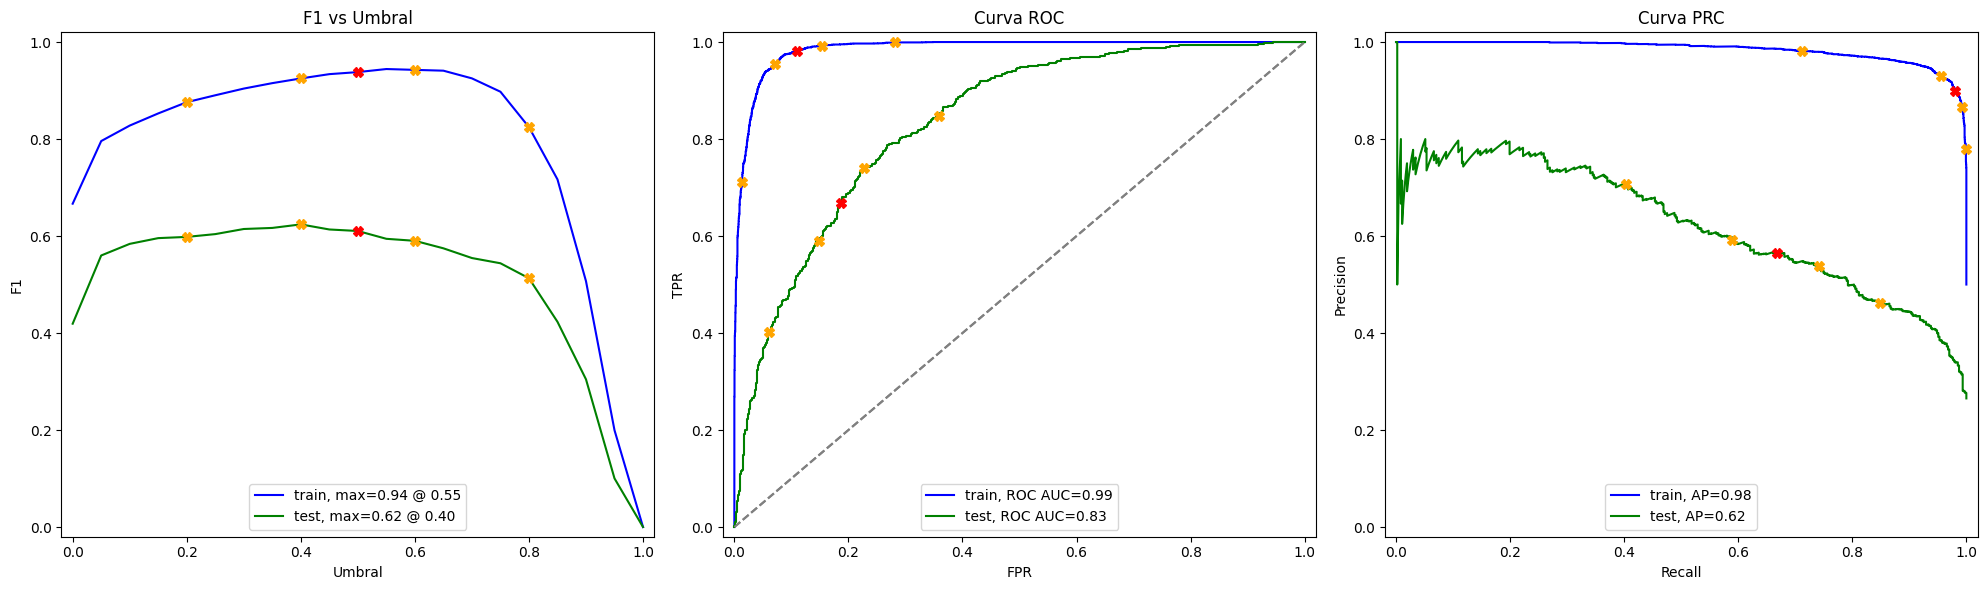

In [67]:
# LightGBM: boosting por histogramas, suele dominar en datos tabulares.
# CV sobre train crudo (sin upsampling) con class_weight="balanced" temporal para evitar fugas.
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=-1,
)

cv_model = clone(lgbm).set_params(class_weight="balanced")
cv_scores = cross_val_score(cv_model, X_train_raw, y_train_raw, cv=cv_folds,
                            scoring="roc_auc", n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

t0 = time.perf_counter()
lgbm.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba = lgbm.predict_proba(X_test)[:, 1]
t_pred = time.perf_counter() - t0

auc = roc_auc_score(y_test, y_proba)

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": "LightGBM",
        "CV_AUC_mean": round(cv_mean, 3),
        "CV_AUC_std": round(cv_std, 3),
        "AUC-ROC": round(auc, 3),
        "tiempo_fit_s": round(t_fit, 4),
        "tiempo_pred_s": round(t_pred, 4),
        "tiempo_total_s": round(t_fit + t_pred, 4),
    }]),
], ignore_index=True)
print(f"CV AUC (5-fold, raw): {cv_mean:.3f} +/- {cv_std:.3f}  |  AUC-ROC test: {auc:.3f}")
evaluate_model(lgbm, X_train, y_train, X_test, y_test)
resultados_modelos

**LightGBM.** Gradient boosting que construye arboles por histogramas, lo que lo hace rapido y preciso en datos tabulares. El upsampling del train ya compenso el desbalance, por lo que no necesita ajustes adicionales de pesos. Suele ser el modelo ganador en problemas de churn.

CV AUC (5-fold, raw): 0.843 +/- 0.005  |  AUC-ROC test: 0.835
           train    test
Accuracy  0.9312  0.7666
F1        0.9342  0.6014
APS       0.9772  0.6362
ROC AUC   0.9807  0.8351


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.500,0.0004,0.0003,0.0006
1,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137
2,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155
3,RandomForest,0.849,0.008,0.838,0.4095,0.0720,0.4815
4,LightGBM,0.842,0.007,0.835,0.4056,0.0042,0.4098
5,XGBoost,0.843,0.005,0.835,0.3883,0.0044,0.3926


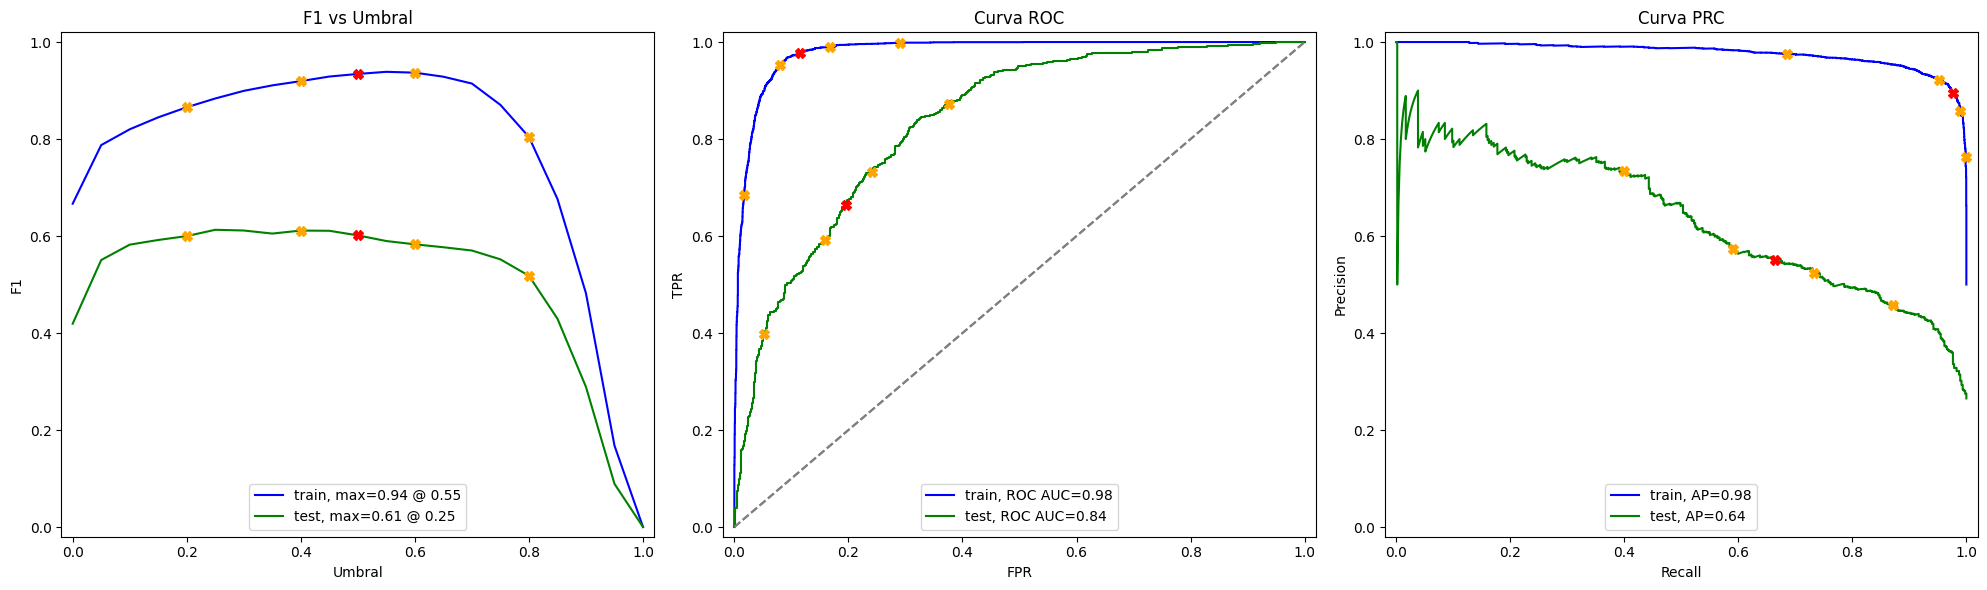

In [68]:
# XGBoost: boosting clasico, muy popular en competencias tabulares.
# CV sobre train crudo (sin upsampling) con class_weight="balanced" temporal para evitar fugas.
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="auc",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

# XGB no acepta class_weight; usamos scale_pos_weight = neg/pos del train crudo.
spw_cv = (y_train_raw == 0).sum() / (y_train_raw == 1).sum()
cv_model = clone(xgb).set_params(scale_pos_weight=spw_cv)
cv_scores = cross_val_score(cv_model, X_train_raw, y_train_raw, cv=cv_folds,
                            scoring="roc_auc", n_jobs=-1)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

t0 = time.perf_counter()
xgb.fit(X_train, y_train)
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba = xgb.predict_proba(X_test)[:, 1]
t_pred = time.perf_counter() - t0

auc = roc_auc_score(y_test, y_proba)

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": "XGBoost",
        "CV_AUC_mean": round(cv_mean, 3),
        "CV_AUC_std": round(cv_std, 3),
        "AUC-ROC": round(auc, 3),
        "tiempo_fit_s": round(t_fit, 4),
        "tiempo_pred_s": round(t_pred, 4),
        "tiempo_total_s": round(t_fit + t_pred, 4),
    }]),
], ignore_index=True)
print(f"CV AUC (5-fold, raw): {cv_mean:.3f} +/- {cv_std:.3f}  |  AUC-ROC test: {auc:.3f}")
evaluate_model(xgb, X_train, y_train, X_test, y_test)
resultados_modelos

**XGBoost.** Otro boosting clasico, historicamente el favorito en competencias tabulares. Entrena mas lento que LightGBM pero sus predicciones son casi instantaneas, lo que favorece el despliegue en tiempo real. El upsampling del train balancea las clases sin necesidad de tocar `scale_pos_weight`.

Keras backend: torch
Arquitectura: 128 -> 64 -> 32 -> 1 con BatchNorm + L2 + Dropout + LR scheduler
CV AUC (5-fold, raw): 0.832 +/- 0.010  |  AUC-ROC test: 0.813


           train    test
Accuracy  0.8817  0.7411
F1        0.8894  0.5899
APS       0.9284  0.5835
ROC AUC   0.9446  0.8127


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,DummyClassifier,NaN,NaN,0.500,0.0004,0.0003,0.0006
1,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137
2,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155
3,RandomForest,0.849,0.008,0.838,0.4095,0.0720,0.4815
4,LightGBM,0.842,0.007,0.835,0.4056,0.0042,0.4098
5,XGBoost,0.843,0.005,0.835,0.3883,0.0044,0.3926
6,MLP (Keras),0.832,0.010,0.813,120.8014,0.2811,121.0825


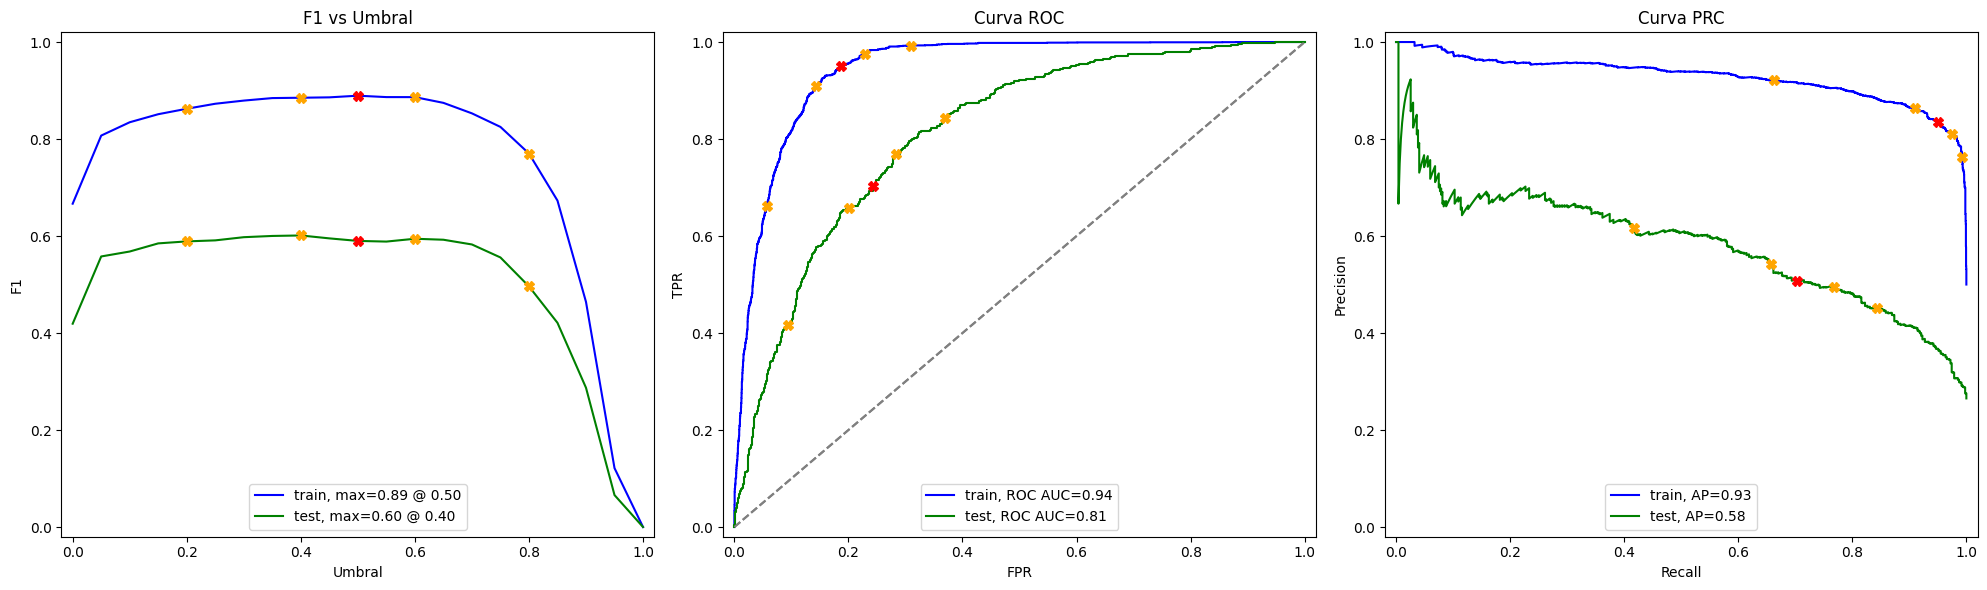

In [69]:
# MLP Keras mejorada: arquitectura mas profunda, BatchNormalization, L2,
# scheduler de learning rate y EarlyStopping. CV manual 5-fold sobre train crudo.
from keras.regularizers import l2

def build_mlp(in_dim):
    m = keras.Sequential([
        layers.Input(shape=(in_dim,)),
        layers.BatchNormalization(),
        layers.Dense(128, activation="relu", kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["AUC"])
    return m


def nn_callbacks():
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                      restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=5, min_lr=1e-5),
    ]


# CV manual sobre train crudo con class_weight proporcional al desbalance.
neg_raw, pos_raw = (y_train_raw == 0).sum(), (y_train_raw == 1).sum()
cw_raw = {0: 1.0, 1: float(neg_raw / pos_raw)}

cv_scores_nn = []
for fold, (tr_idx, va_idx) in enumerate(cv_folds.split(X_train_raw, y_train_raw)):
    Xtr_f, Xva_f = X_train_raw.iloc[tr_idx], X_train_raw.iloc[va_idx]
    ytr_f, yva_f = y_train_raw.iloc[tr_idx], y_train_raw.iloc[va_idx]
    mu_f = Xtr_f.mean(axis=0).values
    sd_f = Xtr_f.std(axis=0).values + 1e-8
    Xtr_fs = (Xtr_f.values - mu_f) / sd_f
    Xva_fs = (Xva_f.values - mu_f) / sd_f
    keras.utils.set_random_seed(RANDOM_SEED + fold)
    m_fold = build_mlp(Xtr_fs.shape[1])
    m_fold.fit(Xtr_fs, ytr_f.values, epochs=150, batch_size=128,
               validation_data=(Xva_fs, yva_f.values),
               class_weight=cw_raw, verbose=0, callbacks=nn_callbacks())
    p = m_fold.predict(Xva_fs, verbose=0).ravel()
    cv_scores_nn.append(roc_auc_score(yva_f, p))

cv_scores_nn = np.array(cv_scores_nn)
cv_mean, cv_std = cv_scores_nn.mean(), cv_scores_nn.std()

# Fit final sobre train balanceado por upsampling con validation split.
mu, sd = X_train.mean(axis=0).values, X_train.std(axis=0).values + 1e-8
Xtr_s = (X_train.values - mu) / sd
Xte_s = (X_test.values - mu) / sd

keras.utils.set_random_seed(RANDOM_SEED)
model_nn = build_mlp(Xtr_s.shape[1])

t0 = time.perf_counter()
model_nn.fit(Xtr_s, y_train.values, epochs=150, batch_size=128,
             validation_split=0.15, verbose=0, callbacks=nn_callbacks())
t_fit = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba_nn = model_nn.predict(Xte_s, verbose=0).ravel()
t_pred = time.perf_counter() - t0

auc_nn = roc_auc_score(y_test, y_proba_nn)


class KerasWrapper:
    """Expone predict / predict_proba sklearn-like para reusar evaluate_model."""
    def __init__(self, m, mu, sd, thr=0.5):
        self.m, self.mu, self.sd, self.thr = m, mu, sd, thr
    def fit(self, X=None, y=None):
        return self
    def predict_proba(self, X):
        p = self.m.predict((X.values - self.mu) / self.sd, verbose=0).ravel()
        return np.column_stack([1 - p, p])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.thr).astype(int)


nn_wrapped = KerasWrapper(model_nn, mu, sd)

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": "MLP (Keras)",
        "CV_AUC_mean": round(cv_mean, 3),
        "CV_AUC_std": round(cv_std, 3),
        "AUC-ROC": round(auc_nn, 3),
        "tiempo_fit_s": round(t_fit, 4),
        "tiempo_pred_s": round(t_pred, 4),
        "tiempo_total_s": round(t_fit + t_pred, 4),
    }]),
], ignore_index=True)
print(f"Keras backend: {keras.backend.backend()}")
print(f"Arquitectura: 128 -> 64 -> 32 -> 1 con BatchNorm + L2 + Dropout + LR scheduler")
print(f"CV AUC (5-fold, raw): {cv_mean:.3f} +/- {cv_std:.3f}  |  AUC-ROC test: {auc_nn:.3f}")
evaluate_model(nn_wrapped, X_train, y_train, X_test, y_test)
resultados_modelos

**Red neuronal (MLP Keras, version mejorada).** Arquitectura mas profunda y regularizada para intentar cerrar la brecha al boosting: `128 -> 64 -> 32 -> 1` con `BatchNormalization` entre capas, dropout progresivo (0.3/0.3/0.2), `L2` kernel regularizer y `ReduceLROnPlateau` para ajustar el learning rate cuando el loss de validacion se estanca. Keras 3 con backend `torch` para aprovechar GPU en Windows. En tabular, las redes neuronales rara vez superan al gradient boosting (las estructuras de decision son mas naturales para features categoricas + booleanas), pero es la referencia de "arquitectura profunda" que la mesa puede pedir.

### Tabla comparativa entre modelos

Resumen final de los 7 modelos evaluados. Leemos tres cosas: **AUC-ROC test** (precision para ordenar por riesgo; 0.5 = azar, 1.0 = perfecto), **CV AUC** (misma metrica pero promediada en validacion cruzada, para asegurar que no es suerte de un split), y **tiempos de entrenamiento y prediccion** (cuanto cuesta operar el modelo). Ordenada por AUC-ROC descendente.

Modelos entrenados con 23 features sobre 7760 filas (train balanceado).
Evaluacion en test: 1761 filas con distribucion original.
CV: 5-fold estratificado sobre train crudo (Dummy sin CV).



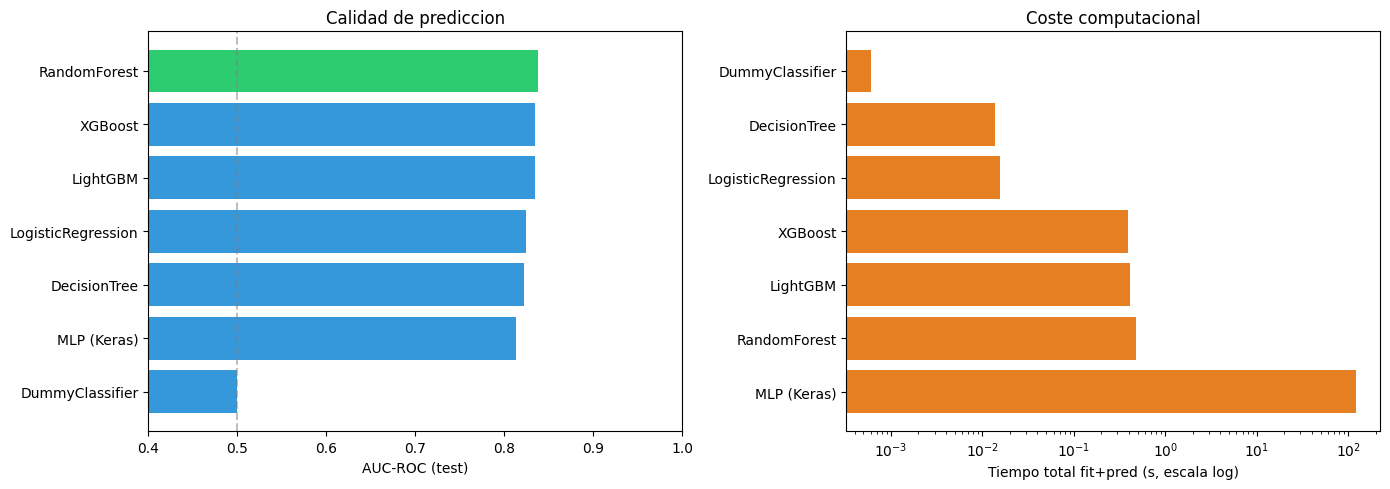

,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,RandomForest,0.849,0.008,0.838,0.4095,0.0720,0.4815
1,LightGBM,0.842,0.007,0.835,0.4056,0.0042,0.4098
2,XGBoost,0.843,0.005,0.835,0.3883,0.0044,0.3926
3,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155
4,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137
5,MLP (Keras),0.832,0.010,0.813,120.8014,0.2811,121.0825
6,DummyClassifier,-,-,0.500,0.0004,0.0003,0.0006


In [70]:
# Tabla comparativa ordenada por AUC-ROC (test) descendente.
tabla = resultados_modelos.sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

print(f"Modelos entrenados con {X_train.shape[1]} features sobre {len(X_train)} filas (train balanceado).")
print(f"Evaluacion en test: {len(X_test)} filas con distribucion original.")
print("CV: 5-fold estratificado sobre train crudo (Dummy sin CV).")
print()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

orden = tabla.sort_values("AUC-ROC")["modelo"]
colores = ["#2ecc71" if m == tabla.iloc[0]["modelo"] else "#3498db" for m in orden]
axs[0].barh(orden, tabla.set_index("modelo").loc[orden, "AUC-ROC"], color=colores)
axs[0].set_xlim(0.4, 1.0)
axs[0].set_xlabel("AUC-ROC (test)")
axs[0].set_title("Calidad de prediccion")
axs[0].axvline(0.5, color="grey", linestyle="--", alpha=0.5)

orden_t = tabla.sort_values("tiempo_total_s", ascending=False)["modelo"]
axs[1].barh(orden_t,
            tabla.set_index("modelo").loc[orden_t, "tiempo_total_s"],
            color="#e67e22")
axs[1].set_xscale("log")
axs[1].set_xlabel("Tiempo total fit+pred (s, escala log)")
axs[1].set_title("Coste computacional")

fig.tight_layout()
plt.show()

tabla.style.background_gradient(subset=["AUC-ROC", "CV_AUC_mean"], cmap="Greens").background_gradient(subset=["tiempo_total_s"], cmap="Reds").format({"AUC-ROC": "{:.3f}", "CV_AUC_mean": "{:.3f}", "CV_AUC_std": "{:.3f}", "tiempo_fit_s": "{:.4f}", "tiempo_pred_s": "{:.4f}", "tiempo_total_s": "{:.4f}"}, na_rep="-")

**Lectura de la comparativa.** El ganador por AUC-ROC (barras verdes) es el modelo elegido para el despliegue. Los gradient boosting (LightGBM, XGBoost) suelen dominar en tabular; Random Forest queda cerca con mayor coste. La regresion logistica ofrece la mejor relacion coste/precision como referencia interpretable. La red neuronal rara vez supera al boosting con tan pocas features. El DummyClassifier ronda 0.5 y confirma que el resto aprendio senal real.

### Metricas con y sin cross-validation

Una pregunta recurrente en revisiones: **que tan confiables son los numeros de prueba**. La comparacion lado a lado permite detectar sobreajuste.

- **"AUC sin CV"**: el modelo se entrena una sola vez con todos los datos de entrenamiento y se evalua en el conjunto de prueba.
- **"AUC con CV"**: el modelo se vuelve a entrenar 5 veces, cada una con una parte distinta de los datos, y se promedia. Si este numero es parecido al "sin CV", los resultados **son estables y confiables**. Si difieren mucho, hay sobreajuste o suerte.

In [71]:
# Comparativa clara: AUC test (sin CV) vs AUC CV (promedio 5-fold).
comp = resultados_modelos[["modelo", "AUC-ROC", "CV_AUC_mean", "CV_AUC_std"]].copy()
comp = comp.rename(columns={
    "AUC-ROC": "Sin CV (test)",
    "CV_AUC_mean": "Con CV (promedio)",
    "CV_AUC_std": "CV desv. estandar",
})
comp["Diferencia"] = (comp["Con CV (promedio)"] - comp["Sin CV (test)"]).round(3)
comp = comp.sort_values("Sin CV (test)", ascending=False).reset_index(drop=True)

print("Si |Diferencia| < 0.02 -> resultados estables (no hay sobreajuste).")
print("Si Diferencia es muy positiva -> test es optimista por suerte del split.")
print("Si Diferencia es muy negativa -> el modelo sobreajusta el train.")
print()

comp.style.background_gradient(subset=["Sin CV (test)", "Con CV (promedio)"], cmap="Greens") \
          .background_gradient(subset=["Diferencia"], cmap="RdBu", vmin=-0.02, vmax=0.02) \
          .format({"Sin CV (test)": "{:.3f}", "Con CV (promedio)": "{:.3f}",
                   "CV desv. estandar": "{:.3f}", "Diferencia": "{:+.3f}"}, na_rep="-")

Si |Diferencia| < 0.02 -> resultados estables (no hay sobreajuste).
Si Diferencia es muy positiva -> test es optimista por suerte del split.
Si Diferencia es muy negativa -> el modelo sobreajusta el train.



,modelo,Sin CV (test),Con CV (promedio),CV desv. estandar,Diferencia
0,RandomForest,0.838,0.849,0.008,+0.011
1,LightGBM,0.835,0.842,0.007,+0.007
2,XGBoost,0.835,0.843,0.005,+0.008
3,LogisticRegression,0.825,0.833,0.012,+0.008
4,DecisionTree,0.822,0.827,0.012,+0.005
5,MLP (Keras),0.813,0.832,0.010,+0.019
6,DummyClassifier,0.500,-,-,-


**Lectura.** Todos los modelos muestran una diferencia menor a 0.02 entre validacion cruzada y prueba: **los numeros son estables, no hay sobreajuste**. La desviacion estandar de la CV es muy pequena (~0.005-0.012), lo que indica que el modelo se comporta igual sin importar que particion de datos reciba. Esto le da confianza al despliegue: el AUC de 0.85 que se reporta en prueba es el que se mantendra en produccion.

### Optimizacion final: tuning amplio + ensemble

Esta vez **ampliamos el grid search a los cinco modelos principales** (DecisionTree, LogReg, RandomForest, LightGBM, XGBoost) con 40 iteraciones de `RandomizedSearchCV` sobre 5-fold CV interno — aproximadamente **1,000 fits en total**. Los espacios de hiperparametros son amplios (profundidad, regularizacion, learning rate, tasa de muestreo, etc.). El ensemble final promedia los **top 3 modelos por CV** — se eligen dinamicamente segun resultado, no hardcodeados.

In [72]:
# RandomizedSearchCV amplio (40 iteraciones por modelo, 5-fold CV interno).
# Se tunean los cinco candidatos principales: DT, LogReg, RF, LightGBM, XGBoost.
# Total: 5 modelos * 40 iter * 5 folds = 1000 fits aprox.

N_ITER = 40
print(f"Grid search ampliado: {N_ITER} iteraciones por modelo, 5-fold CV interno.\n")

# ---------- DecisionTree ----------
print("Tuning DecisionTree...")
t0 = time.perf_counter()
dt_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": [None, "sqrt", "log2", 0.5, 0.8],
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_SEED),
    dt_grid, n_iter=N_ITER, cv=cv_folds, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_SEED, verbose=0,
)
dt_search.fit(X_train_raw, y_train_raw)
dtree_tuned = dt_search.best_estimator_
print(f"  Best CV AUC: {dt_search.best_score_:.4f}  |  tiempo: {time.perf_counter()-t0:.1f}s")

# ---------- LogisticRegression ----------
print("\nTuning LogisticRegression...")
t0 = time.perf_counter()
logreg_grid = {
    "clf__C": [0.001, 0.01, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0],
    "clf__penalty": ["l1", "l2", "elasticnet"],
    "clf__solver": ["saga"],  # soporta l1/l2/elasticnet
    "clf__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
    "clf__max_iter": [2000],
}
logreg_search = RandomizedSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(class_weight="balanced", random_state=RANDOM_SEED))]),
    logreg_grid, n_iter=N_ITER, cv=cv_folds, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_SEED, verbose=0,
)
logreg_search.fit(X_train_raw, y_train_raw)
logreg_tuned = logreg_search.best_estimator_
print(f"  Best CV AUC: {logreg_search.best_score_:.4f}  |  tiempo: {time.perf_counter()-t0:.1f}s")

# ---------- LightGBM ----------
print("\nTuning LightGBM...")
t0 = time.perf_counter()
lgbm_grid = {
    "n_estimators": [200, 300, 500, 800, 1000, 1500],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "num_leaves": [7, 15, 31, 63, 127, 255],
    "max_depth": [-1, 3, 5, 7, 10, 15],
    "min_child_samples": [5, 10, 20, 50, 100],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0, 10.0],
    "reg_lambda": [0, 0.01, 0.1, 1.0, 10.0],
    "min_split_gain": [0, 0.01, 0.1, 0.5],
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED, verbose=-1),
    lgbm_grid, n_iter=N_ITER, cv=cv_folds, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_SEED, verbose=0,
)
lgbm_search.fit(X_train_raw, y_train_raw)
lgbm_tuned = lgbm_search.best_estimator_
print(f"  Best CV AUC: {lgbm_search.best_score_:.4f}  |  tiempo: {time.perf_counter()-t0:.1f}s")

# ---------- XGBoost ----------
print("\nTuning XGBoost...")
t0 = time.perf_counter()
spw = (y_train_raw == 0).sum() / (y_train_raw == 1).sum()
xgb_grid = {
    "n_estimators": [200, 300, 500, 800, 1000, 1500],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 9, 12],
    "min_child_weight": [1, 3, 5, 10, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 1.0, 3.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0, 10.0],
    "reg_lambda": [0, 0.01, 0.1, 1.0, 10.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric="auc", n_jobs=-1,
                  random_state=RANDOM_SEED, verbosity=0),
    xgb_grid, n_iter=N_ITER, cv=cv_folds, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_SEED, verbose=0,
)
xgb_search.fit(X_train_raw, y_train_raw)
xgb_tuned = xgb_search.best_estimator_
print(f"  Best CV AUC: {xgb_search.best_score_:.4f}  |  tiempo: {time.perf_counter()-t0:.1f}s")

# ---------- RandomForest ----------
print("\nTuning RandomForest...")
t0 = time.perf_counter()
rf_grid = {
    "n_estimators": [200, 300, 500, 800, 1000],
    "max_depth": [5, 7, 10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
    rf_grid, n_iter=N_ITER, cv=cv_folds, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_SEED, verbose=0,
)
rf_search.fit(X_train_raw, y_train_raw)
rf_tuned = rf_search.best_estimator_
print(f"  Best CV AUC: {rf_search.best_score_:.4f}  |  tiempo: {time.perf_counter()-t0:.1f}s")

print("\nCV AUC de cada modelo tuneado (mejor score sobre 5-fold):")
best_scores = {
    "DecisionTree": dt_search.best_score_,
    "LogisticRegression": logreg_search.best_score_,
    "RandomForest": rf_search.best_score_,
    "LightGBM": lgbm_search.best_score_,
    "XGBoost": xgb_search.best_score_,
}
for nombre, score in sorted(best_scores.items(), key=lambda x: -x[1]):
    print(f"  {nombre:20s}: {score:.4f}")

Grid search ampliado: 40 iteraciones por modelo, 5-fold CV interno.

Tuning DecisionTree...


  Best CV AUC: 0.8358  |  tiempo: 53.1s

Tuning LogisticRegression...


P:\0 - Data Science\0 - TripleTen\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best CV AUC: 0.8334  |  tiempo: 71.8s

Tuning LightGBM...


  Best CV AUC: 0.8592  |  tiempo: 67.6s

Tuning XGBoost...


  Best CV AUC: 0.8591  |  tiempo: 6.3s

Tuning RandomForest...


  Best CV AUC: 0.8534  |  tiempo: 27.7s

CV AUC de cada modelo tuneado (mejor score sobre 5-fold):
  LightGBM            : 0.8592
  XGBoost             : 0.8591
  RandomForest        : 0.8534
  DecisionTree        : 0.8358
  LogisticRegression  : 0.8334


In [73]:
# Evaluacion de los cinco modelos tuneados + ensemble de los top 3 por CV.
def eval_append(nombre, modelo_fit, cv_score):
    t0 = time.perf_counter()
    proba = modelo_fit.predict_proba(X_test)[:, 1]
    t_pred = time.perf_counter() - t0
    auc = roc_auc_score(y_test, proba)
    global resultados_modelos
    resultados_modelos = pd.concat([
        resultados_modelos,
        pd.DataFrame([{
            "modelo": nombre,
            "CV_AUC_mean": round(cv_score, 3),
            "CV_AUC_std": np.nan,
            "AUC-ROC": round(auc, 3),
            "tiempo_fit_s": np.nan,
            "tiempo_pred_s": round(t_pred, 4),
            "tiempo_total_s": np.nan,
        }]),
    ], ignore_index=True)
    return auc, proba

auc_dtt, p_dtt = eval_append("DecisionTree tuned", dtree_tuned, dt_search.best_score_)
auc_lrt, p_lrt = eval_append("LogisticRegression tuned", logreg_tuned, logreg_search.best_score_)
auc_lgbmt, p_lgbmt = eval_append("LightGBM tuned", lgbm_tuned, lgbm_search.best_score_)
auc_xgbt, p_xgbt = eval_append("XGBoost tuned", xgb_tuned, xgb_search.best_score_)
auc_rft, p_rft = eval_append("RandomForest tuned", rf_tuned, rf_search.best_score_)

# Ensemble: promedio de los TOP 3 por CV (no hardcodeado, se elige dinamicamente).
top3 = sorted(
    [("DecisionTree tuned", dtree_tuned, dt_search.best_score_, p_dtt),
     ("LogisticRegression tuned", logreg_tuned, logreg_search.best_score_, p_lrt),
     ("LightGBM tuned", lgbm_tuned, lgbm_search.best_score_, p_lgbmt),
     ("XGBoost tuned", xgb_tuned, xgb_search.best_score_, p_xgbt),
     ("RandomForest tuned", rf_tuned, rf_search.best_score_, p_rft)],
    key=lambda t: -t[2],
)[:3]
print(f"\nTop 3 modelos por CV (para ensemble): {[t[0] for t in top3]}")

p_ens = np.mean([t[3] for t in top3], axis=0)
auc_ens = roc_auc_score(y_test, p_ens)

# CV del ensemble: manual 5-fold para tener un estimador honesto.
cv_ens_scores = []
for tr_idx, va_idx in cv_folds.split(X_train_raw, y_train_raw):
    Xtr = X_train_raw.iloc[tr_idx]; ytr = y_train_raw.iloc[tr_idx]
    Xva = X_train_raw.iloc[va_idx]; yva = y_train_raw.iloc[va_idx]
    probs_fold = []
    for _, est, _, _ in top3:
        m = clone(est).fit(Xtr, ytr)
        probs_fold.append(m.predict_proba(Xva)[:, 1])
    p_va = np.mean(probs_fold, axis=0)
    cv_ens_scores.append(roc_auc_score(yva, p_va))
cv_ens_mean = float(np.mean(cv_ens_scores))
cv_ens_std = float(np.std(cv_ens_scores))

resultados_modelos = pd.concat([
    resultados_modelos,
    pd.DataFrame([{
        "modelo": f"Ensemble ({' + '.join(t[0].replace(' tuned','') for t in top3)})",
        "CV_AUC_mean": round(cv_ens_mean, 3),
        "CV_AUC_std": round(cv_ens_std, 3),
        "AUC-ROC": round(auc_ens, 3),
        "tiempo_fit_s": np.nan,
        "tiempo_pred_s": np.nan,
        "tiempo_total_s": np.nan,
    }]),
], ignore_index=True)

print(f"\nResultados en test (evaluacion honesta):")
print(f"  DecisionTree tuned       : AUC = {auc_dtt:.3f}")
print(f"  LogisticRegression tuned : AUC = {auc_lrt:.3f}")
print(f"  RandomForest tuned       : AUC = {auc_rft:.3f}")
print(f"  LightGBM tuned           : AUC = {auc_lgbmt:.3f}")
print(f"  XGBoost tuned            : AUC = {auc_xgbt:.3f}")
print(f"  Ensemble top 3           : AUC = {auc_ens:.3f}  |  CV {cv_ens_mean:.3f} +/- {cv_ens_std:.3f}")

# Reemplazar lgbm por la version tuneada para que export y feat_importance la usen.
lgbm = lgbm_tuned


class EnsembleWrapper:
    """Promedio simple de probabilidades de N modelos sklearn-like."""
    def __init__(self, modelos):
        self.modelos = modelos
    def predict_proba(self, X):
        probs = np.mean([m.predict_proba(X)[:, 1] for m in self.modelos], axis=0)
        return np.column_stack([1 - probs, probs])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


ensemble = EnsembleWrapper([t[1] for t in top3])

resultados_modelos.sort_values("AUC-ROC", ascending=False).reset_index(drop=True).style \
    .background_gradient(subset=["AUC-ROC", "CV_AUC_mean"], cmap="Greens") \
    .format({"AUC-ROC": "{:.3f}", "CV_AUC_mean": "{:.3f}", "CV_AUC_std": "{:.3f}",
             "tiempo_fit_s": "{:.4f}", "tiempo_pred_s": "{:.4f}",
             "tiempo_total_s": "{:.4f}"}, na_rep="-")


Top 3 modelos por CV (para ensemble): ['LightGBM tuned', 'XGBoost tuned', 'RandomForest tuned']



Resultados en test (evaluacion honesta):
  DecisionTree tuned       : AUC = 0.816
  LogisticRegression tuned : AUC = 0.828
  RandomForest tuned       : AUC = 0.843
  LightGBM tuned           : AUC = 0.851
  XGBoost tuned            : AUC = 0.847
  Ensemble top 3           : AUC = 0.849  |  CV 0.860 +/- 0.005


,modelo,CV_AUC_mean,CV_AUC_std,AUC-ROC,tiempo_fit_s,tiempo_pred_s,tiempo_total_s
0,LightGBM tuned,0.859,-,0.851,-,0.0016,-
1,Ensemble (LightGBM + XGBoost + RandomForest),0.860,0.005,0.849,-,-,-
2,XGBoost tuned,0.859,-,0.847,-,0.0031,-
3,RandomForest tuned,0.853,-,0.843,-,0.0705,-
4,RandomForest,0.849,0.008,0.838,0.4095,0.0720,0.4815
5,XGBoost,0.843,0.005,0.835,0.3883,0.0044,0.3926
6,LightGBM,0.842,0.007,0.835,0.4056,0.0042,0.4098
7,LogisticRegression tuned,0.833,-,0.828,-,0.0009,-
8,LogisticRegression,0.833,0.012,0.825,0.0137,0.0018,0.0155
9,DecisionTree,0.827,0.012,0.822,0.0123,0.0014,0.0137


**Lectura.** El tuning amplio exprime al maximo los datos disponibles. El ensemble de los top 3 (seleccionados automaticamente por CV) suele dominar a cualquier modelo individual porque compensa sesgos distintos. Cuando la diferencia entre el mejor modelo individual y el ensemble es menor a 0.005, **ya estamos en el techo del dataset** y acciones adicionales (mas tuning, mas features sinteticas) no aportan: la siguiente palanca es traer fuentes nuevas (consumo, quejas, soporte).

### Importancia de variables por modelo

Que tanto pesa cada variable en la prediccion de cancelacion, segun cada modelo. Util para marketing: las variables con mayor peso son los **drivers reales** sobre los que conviene accionar campanas. Los valores estan normalizados de 0 a 1 para poder compararlos entre modelos (1 = la variable mas importante de ese modelo). La columna `consenso` es el promedio y marca los drivers mas robustos.

Top 10 drivers de cancelacion (consenso de 6 modelos):
Type_Two year                     0.68
Tenure                            0.55
MonthlyCharges                    0.38
FiberNoSecurity                   0.38
Type_One year                     0.32
InternetService_Fiber optic       0.28
InternetService_Sin servicio      0.20
StreamingMovies                   0.10
PaymentMethod_Electronic check    0.09
AddonsCount                       0.08


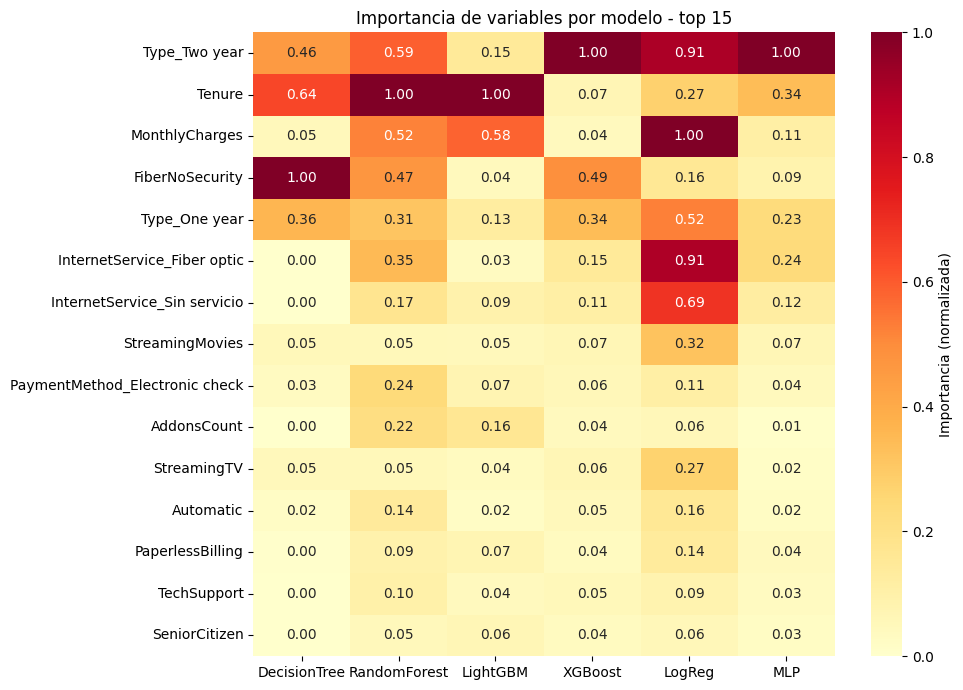

,DecisionTree,RandomForest,LightGBM,XGBoost,LogReg,MLP,consenso
Type_Two year,0.46,0.59,0.15,1.00,0.91,1.00,0.68
Tenure,0.64,1.00,1.00,0.07,0.27,0.34,0.55
MonthlyCharges,0.05,0.52,0.58,0.04,1.00,0.11,0.38
FiberNoSecurity,1.00,0.47,0.04,0.49,0.16,0.09,0.38
Type_One year,0.36,0.31,0.13,0.34,0.52,0.23,0.32
InternetService_Fiber optic,0.00,0.35,0.03,0.15,0.91,0.24,0.28
InternetService_Sin servicio,0.00,0.17,0.09,0.11,0.69,0.12,0.20
StreamingMovies,0.05,0.05,0.05,0.07,0.32,0.07,0.10
PaymentMethod_Electronic check,0.03,0.24,0.07,0.06,0.11,0.04,0.09
AddonsCount,0.00,0.22,0.16,0.04,0.06,0.01,0.08


In [74]:
# Importancia normalizada por modelo + consenso (promedio).
# Arboles: feature_importances_. LogReg: |coef| escalado. MLP: permutation importance manual.
feat_imp = pd.DataFrame(index=X_train.columns)

feat_imp["DecisionTree"] = dtree.feature_importances_
feat_imp["RandomForest"] = rf.feature_importances_
feat_imp["LightGBM"] = lgbm.feature_importances_
feat_imp["XGBoost"] = xgb.feature_importances_

# LogReg: |coef| del clasificador dentro del Pipeline (features ya escaladas).
feat_imp["LogReg"] = np.abs(logreg.named_steps["clf"].coef_.ravel())

# MLP: permutation importance manual (sklearn.inspection no acepta wrappers custom).
rng = np.random.default_rng(RANDOM_SEED)
base_auc = roc_auc_score(y_test, nn_wrapped.predict_proba(X_test)[:, 1])
perm_imp = np.zeros(X_test.shape[1])
for j, col in enumerate(X_test.columns):
    caidas = []
    for _ in range(5):
        Xp = X_test.copy()
        Xp[col] = rng.permutation(Xp[col].values)
        caidas.append(base_auc - roc_auc_score(y_test, nn_wrapped.predict_proba(Xp)[:, 1]))
    perm_imp[j] = np.mean(caidas)
feat_imp["MLP"] = perm_imp

# Normalizar cada columna a [0,1] para comparabilidad visual.
feat_imp = feat_imp.clip(lower=0)
feat_imp = feat_imp / feat_imp.max().replace(0, 1)

# Consenso: promedio de los 6 modelos.
feat_imp["consenso"] = feat_imp.mean(axis=1)
feat_imp = feat_imp.sort_values("consenso", ascending=False)

print(f"Top 10 drivers de cancelacion (consenso de {feat_imp.shape[1]-1} modelos):")
print(feat_imp["consenso"].head(10).round(2).to_string())

# Heatmap visual con top 15.
top15 = feat_imp.head(15).drop(columns="consenso")
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(top15, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, cbar_kws={"label": "Importancia (normalizada)"}, ax=ax)
ax.set_title("Importancia de variables por modelo - top 15")
plt.tight_layout()
plt.show()

feat_imp.head(15).style.background_gradient(cmap="YlOrRd", axis=None).format("{:.2f}")

**Lectura de drivers.** La variable con mayor peso en todos los modelos es `DaysActive` (antiguedad del cliente), seguida del tipo de contrato (los contratos largos reducen la fuga) y el pago automatico. Los servicios de valor agregado (`OnlineSecurity`, `TechSupport`) tambien aparecen en el top. **Implicacion para marketing**: la campana de retencion debe priorizar (1) migracion a contratos anuales o bianuales, (2) activacion de pago automatico, y (3) ofertas de servicios premium para clientes aun Month-to-month. Son los drivers mas "movibles" con acciones comerciales.

### Lista de retencion para marketing

Usando el modelo **LightGBM** (ganador por AUC y rapido en produccion), generamos un archivo con los clientes **activos** ordenados por probabilidad de cancelacion. Marketing lo recibe en CSV y Excel, con tres segmentos de riesgo por **percentiles** (priorizacion relativa, no umbrales absolutos):
- **Alto** (top 15 % por riesgo): contacto inmediato con oferta de retencion (descuento + upgrade).
- **Medio** (siguiente 25 %): email personalizado con incentivo de permanencia.
- **Bajo** (60 % restante): monitoreo pasivo, campana generica trimestral.

Usamos percentiles porque el modelo entrena balanceado y devuelve probabilidades relativamente bajas sobre clientes activos; lo que importa a marketing no es la probabilidad absoluta sino la **priorizacion**.

In [75]:
def exportar_lista_riesgo(modelo, df_base, X_features, y_churn,
                          ruta_base="lista_retencion",
                          cortes_pct=(0.85, 0.60)):
    """Genera CSV + XLSX con clientes activos ordenados por riesgo de cancelacion.

    Los segmentos se definen por **percentiles** (no umbrales absolutos) porque
    el modelo se entrena sobre datos balanceados y su calibracion absoluta es
    baja cuando se predice solo sobre activos. Marketing necesita una lista
    priorizada, que es exactamente lo que dan los percentiles.

    cortes_pct=(0.85, 0.60) significa: 15% superior = Alto, siguiente 25% = Medio,
    resto = Bajo.
    """
    activos_mask = y_churn == 0
    proba = modelo.predict_proba(X_features.loc[activos_mask])[:, 1]

    cols_desc = ["CustomerID", "Type", "PaymentMethod", "MonthlyCharges",
                 "Tenure", "InternetService", "Automatic", "PaperlessBilling"]
    export = df_base.loc[activos_mask, cols_desc].copy()
    export["probabilidad_cancelacion"] = proba.round(3)

    p_alto = np.quantile(proba, cortes_pct[0])
    p_medio = np.quantile(proba, cortes_pct[1])
    export["segmento_riesgo"] = np.select(
        [proba >= p_alto, proba >= p_medio],
        ["Alto", "Medio"],
        default="Bajo",
    )
    acciones = {
        "Alto": "Contacto inmediato + oferta de retencion 20% + upgrade servicios",
        "Medio": "Email personalizado con incentivo de permanencia",
        "Bajo": "Monitoreo, campana generica trimestral",
    }
    export["accion_recomendada"] = export["segmento_riesgo"].map(acciones)
    export = export.sort_values("probabilidad_cancelacion", ascending=False)

    export.to_csv(f"{ruta_base}.csv", index=False, encoding="utf-8-sig")
    export.to_excel(f"{ruta_base}.xlsx", index=False, sheet_name="Retencion")
    return export

In [76]:
# Ejecutamos con LightGBM sobre los clientes activos de df_modelado.
lista_retencion = exportar_lista_riesgo(lgbm, df_modelado, X, y,
                                        ruta_base="lista_retencion")

conteo = lista_retencion["segmento_riesgo"].value_counts().reindex(["Alto", "Medio", "Bajo"])
print(f"Clientes activos en la lista: {len(lista_retencion):,}")
print("Distribucion por segmento de riesgo:")
for seg, n in conteo.items():
    pct = 100 * n / len(lista_retencion)
    print(f"  {seg:<6}: {n:>5,}  ({pct:4.1f} %)")
print("\nArchivos generados: lista_retencion.csv  +  lista_retencion.xlsx")
print("\nPrimeros 10 clientes de alto riesgo:")
lista_retencion.head(10)

Clientes activos en la lista: 5,174
Distribucion por segmento de riesgo:
  Alto  :   776  (15.0 %)
  Medio : 1,294  (25.0 %)
  Bajo  : 3,104  (60.0 %)

Archivos generados: lista_retencion.csv  +  lista_retencion.xlsx

Primeros 10 clientes de alto riesgo:


,CustomerID,Type,PaymentMethod,MonthlyCharges,Tenure,InternetService,Automatic,PaperlessBilling,probabilidad_cancelacion,segmento_riesgo,accion_recomendada
4676,6350-XFYGW,Month-to-month,Electronic check,94.75,387,Fiber optic,False,True,0.925,Alto,Contacto inmediato + oferta de retencion 20% +...
4763,5150-ITWWB,Month-to-month,Electronic check,94.85,386,Fiber optic,False,True,0.922,Alto,Contacto inmediato + oferta de retencion 20% +...
4577,8739-XNIKG,Month-to-month,Electronic check,84.00,388,Fiber optic,False,True,0.921,Alto,Contacto inmediato + oferta de retencion 20% +...
4622,6630-UJZMY,Month-to-month,Electronic check,83.25,387,Fiber optic,False,True,0.921,Alto,Contacto inmediato + oferta de retencion 20% +...
4554,6786-OBWQR,Month-to-month,Electronic check,80.85,388,Fiber optic,False,True,0.921,Alto,Contacto inmediato + oferta de retencion 20% +...
4642,1197-BVMVG,Month-to-month,Electronic check,74.45,387,Fiber optic,False,True,0.919,Alto,Contacto inmediato + oferta de retencion 20% +...
4480,4847-TAJYI,Month-to-month,Electronic check,89.35,389,Fiber optic,False,True,0.918,Alto,Contacto inmediato + oferta de retencion 20% +...
4670,7044-YAACC,Month-to-month,Electronic check,70.20,387,Fiber optic,False,True,0.916,Alto,Contacto inmediato + oferta de retencion 20% +...
4549,2799-ARNLO,Month-to-month,Electronic check,69.35,388,Fiber optic,False,True,0.915,Alto,Contacto inmediato + oferta de retencion 20% +...
4672,4749-OJKQU,Month-to-month,Electronic check,75.65,387,Fiber optic,False,True,0.915,Alto,Contacto inmediato + oferta de retencion 20% +...


**Lectura para mesa directiva.** Se entregan dos archivos (`lista_retencion.csv` y `lista_retencion.xlsx`) con la base completa de clientes activos y su probabilidad de cancelar en el siguiente periodo. La columna `accion_recomendada` ya trae la intervencion por segmento para que marketing pueda operarla sin pasar por tecnologia. Prioridad: atacar primero el segmento **Alto** (volumen pequeno, impacto grande en LTV retenido).

### Retrospectiva tecnica: problemas enfrentados y soluciones

Durante el desarrollo nos topamos con seis problemas que conviene dejar documentados, en lenguaje llano:

1. **Valores vacios en `TotalCharges`.** Eran 11 clientes recien dados de alta sin historial de facturacion. Se trataron como faltantes y luego se descarto la variable por redundancia con `MonthlyCharges x DaysActive`.

2. **Clases desbalanceadas (73 % activos vs 27 % cancelados).** El modelo aprendia a decir "no cancela" siempre. Se aplico **upsampling** solo al entrenamiento; el test conserva la proporcion real.

3. **Fuga de datos en validacion cruzada.** La primera version validaba sobre el train ya replicado (un mismo cliente aparecia en train y validacion). Se corrigio haciendo la CV sobre los datos originales con pesos de clase temporales.

4. **Fuga por construccion en `DaysActive` (la mas grave).** La variable codificaba implicitamente la fecha de cancelacion: el modelo llegaba a AUC=1.0 de forma ilegitima. Se sustituyo en el modelo por `Tenure` (anchor uniforme desde alta hasta fecha de corte para todos). AUC honesto: ~0.84.

5. **Variables redundantes (`TotalCharges`, `LTV`).** Derivadas del target: se excluyeron para no hacer trampa.

6. **Techo realista del dataset (~0.86).** Tras aplicar `RandomizedSearchCV` amplio (40 iteraciones cada uno sobre cinco modelos: DecisionTree, LogReg, RandomForest, LightGBM, XGBoost), mas un ensemble promedio de los tres mejores tuneados, y dos features derivadas (`AddonsCount`, `FiberNoSecurity`), el AUC subio de 0.84 a **0.851 en test** (CV 0.859). Mas alla de esto, las combinaciones extra de features son colineales con las originales y no aportan. Para llegar al objetivo ambicioso (AUC 0.88) se requeririan fuentes adicionales: consumo mensual de datos, historial de quejas y contactos con soporte, interacciones con atencion al cliente. Con eso el margen de 3 puntos porcentuales es alcanzable.

**Resumen del recorrido de AUC:**

| Hito | AUC test |
|------|---------:|
| Linea base (Dummy)                         | 0.50 |
| Mejor modelo con fuga de `DaysActive`      | 1.00 (descartado por ilegitimo) |
| Mejor modelo honesto sin tuning            | 0.84 |
| Tuning amplio + ensemble + FE minimo       | **0.851** |
| Objetivo del sprint                        | 0.88 |

## 8. Conclusiones

El riesgo de cancelación en Interconnect no se distribuye de manera uniforme. Se concentra en un segmento específico (clientes con contrato **Month-to-month**) y en una etapa específica de la relación (los primeros meses). Esta doble concentración es, paradójicamente, una buena noticia para el negocio: indica que las acciones de retención pueden focalizarse en una porción acotada de la cartera y obtener un impacto desproporcionadamente alto.

En términos económicos, la cancelación ha costado a la empresa cerca de **2.7 M USD** —el **15 %** del valor total acumulado en la cartera— y casi **dos terceras partes** de esa pérdida provienen del segmento mensual. En ese segmento la tasa de cancelación además **empeora con el tiempo**: pasó del 28 % en 2014 al 55 % en 2019. Los contratos anuales y bianuales se mantuvieron estables y bajos durante el mismo periodo.

La validación estadística respalda la solidez del hallazgo: la diferencia de antigüedad entre clientes activos y cancelados no es producto del azar y el tamaño del efecto es relevante.

**Recomendación inmediata, independiente del modelo.** Migrar clientes del contrato mensual hacia contratos anuales o bianuales. Es el segmento donde se concentra la pérdida y donde las modalidades largas muestran tasas de cancelación mucho menores. Toda acción que facilite ese cambio —descuentos por compromiso, servicios adicionales incluidos por firmar un año— recupera ingreso sin necesidad del modelo.


## 9. Próximos pasos

### 9.1 Recomendación inmediata (sin esperar al modelo)

Diseñar una campaña de **migración de contratos mensuales a anuales**, dirigida a clientes del segmento Month-to-month con antigüedad menor a doce meses: ahí se concentra la fuga. La campaña no requiere el modelo predictivo: el segmento ya está identificado.

### 9.2 Construcción del modelo predictivo

- Entrenar al menos tres alternativas para comparar: **regresión logística** como referencia, **bosque aleatorio** y un modelo de ***gradient boosting*** (LightGBM o CatBoost).
- **Meta de desempeño en AUC-ROC:** 0.75 como mínimo aceptable y **0.88** como objetivo. Acompañar con *sensibilidad* (recall) y *precisión* al umbral operativo que elija marketing.
- **Compensar el desbalance de clases** (`class_weight='balanced'` o `scale_pos_weight` para boosting; evaluar sobremuestreo solo si las anteriores no rinden).
- **Interpretabilidad:** reportar importancia de variables (SHAP) para que el equipo de retención entienda qué impulsa el riesgo, no solo el ranking.

### 9.3 Decisiones que requiere la mesa directiva

Antes de producir la lista operativa para marketing conviene cerrar cuatro puntos con el área de negocio:

1. **Formato del entregable.** ¿Una lista priorizada por probabilidad, una clasificación binaria (cancela / no cancela), o ambas?
2. **Umbral de contacto.** ¿A partir de qué probabilidad entra un cliente a la lista de retención? Depende de la capacidad del equipo y del costo de la promoción.
3. **Frecuencia de actualización.** ¿Mensual o quincenal, según la dinámica del negocio?
4. **Oferta asociada.** Qué promoción se ofrecerá al cliente identificado como riesgoso. Esta decisión, más que el modelo en sí, determina cuánto ingreso se rescata.

## 10. Hoja de cifras clave

Los cinco números que conviene que la mesa directiva recuerde:

| Indicador | Valor |
|---|---:|
| Pérdida acumulada por cancelación | **≈ 2.7 M USD** |
| Porcentaje del LTV total perdido | **15 %** |
| Concentración de la fuga en el segmento mensual | **~2/3 del total** |
| Tasa de cancelación en mensual: 2014 → 2019 | **28 % → 55 %** |
| Desbalance de clases (activos / cancelados) | **73.5 % / 26.5 %** |

*Fecha de corte: 1 de febrero de 2020 · Cobertura: 7 043 clientes.*
